## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "Base"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


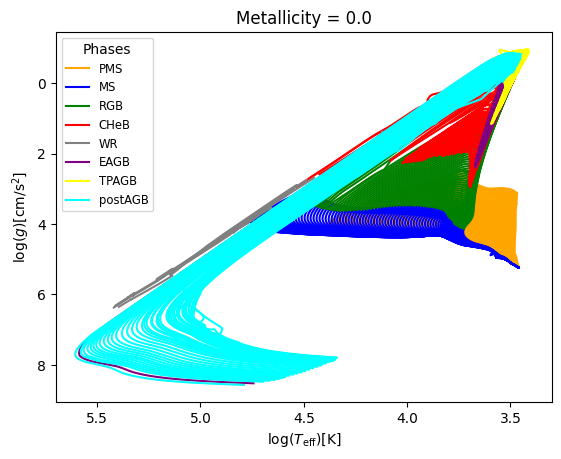

In [4]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
633331,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
633332,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
633333,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
633334,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


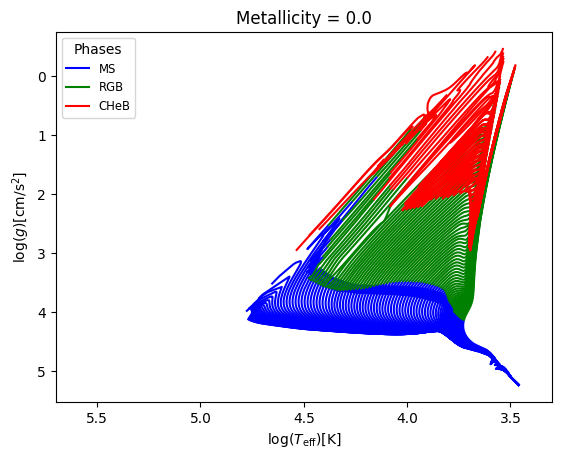

In [5]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [6]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.1222, Median : 8.15

log_Teff  : Range : 3.34 - 5.3788, Mean : 4.0309, Median : 3.9786

log_g  : Range : -1.08 - 7.9405, Mean : 3.515, Median : 3.8557

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 298.5448, Mean : 11.3677, Median : 2.8697

log_R  : Range : -1.86 - 3.1298, Mean : 0.7296, Median : 0.6976



In [7]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 298.5447575808816
Median value in train data for the star_mass parameter: 2.8645630497037122
Mean value in train data for the star_mass parameter: 11.388311127703718

Range in train data for the log_R parameter : -1.861069007171269 - 3.1297545143214007
Median value in train data for the log_R parameter: 0.6972414370384683
Mean value in train data for the log_R parameter: 0.7295870328373154

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999982496805748 - 295.93050489035244
Median value in test data for the star_mass parameter: 2.889820745250999
Mean value in test data for the star_mass parameter: 11.305983429853224

Range in test data for the log_R parameter : -1.859644360427887 - 3.114776659195789
Median value in test data for the log_R parameter: 0.6988164702607209
Mean value in test data for the log_R parameter: 0.7295693446897737

(475002, 4) (158334, 4)
(475

## Model training

### Linear regression

In [10]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...
0.0999979840073621 - 298.5447575808816

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.2729320152593433
  RMSE :  22.4488919414279
  MAE :  13.033422245611522
  MedAE :  11.068983544383217
  CORR :  0.5334771169192601
  MAX_ER :  257.8052486889697
  Percentiles : 
    75th percentile :  15.139787846242772
    90th percentile :  18.652891239930657
    95th percentile :  21.100031036799137
    99th percentile :  102.90301962739845

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.31780480327703364
  RMSE :  24.369214026570532
  MAE :  10.19273825964967
  MedAE :  5.5255520552792525
  CORR :  0.5956484957644704
  MAX_ER :  247.272892099655
  Percentiles : 
    75th percentile :  11.071910063519333
    90th percentile :  14.157846252588993
    95th percentile :  22.74116807655939
    99th percenti

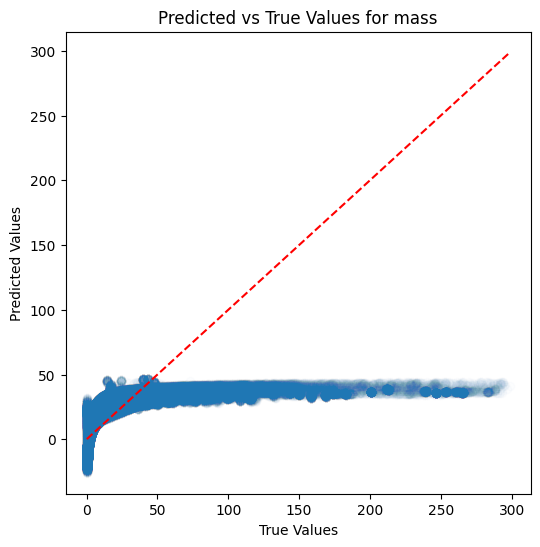

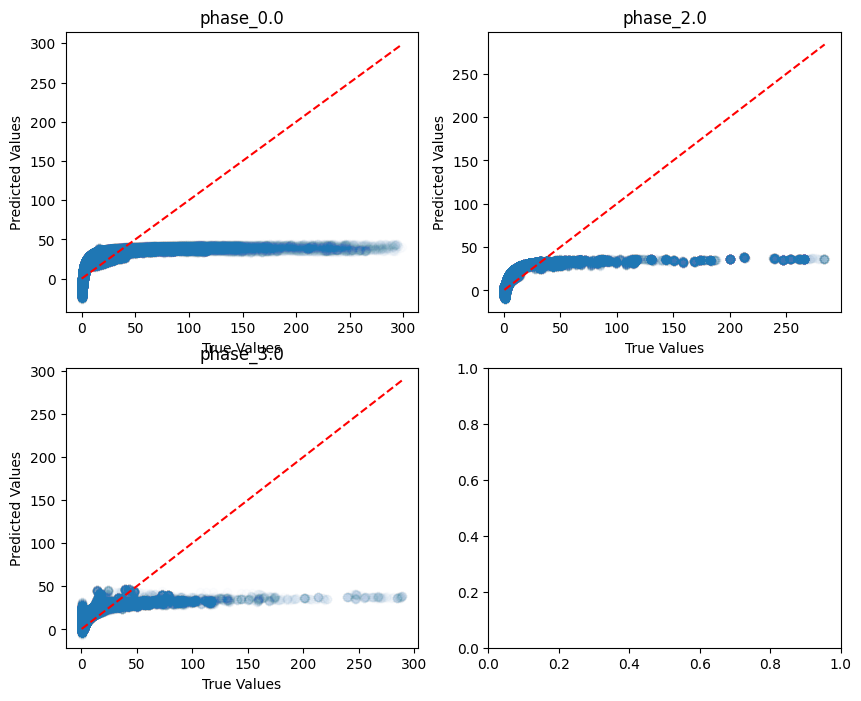

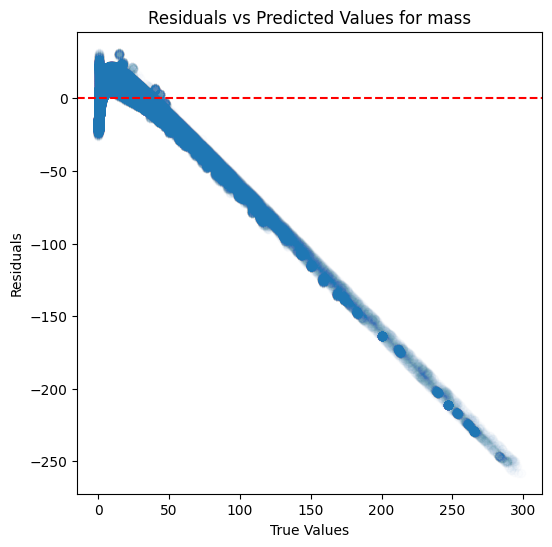

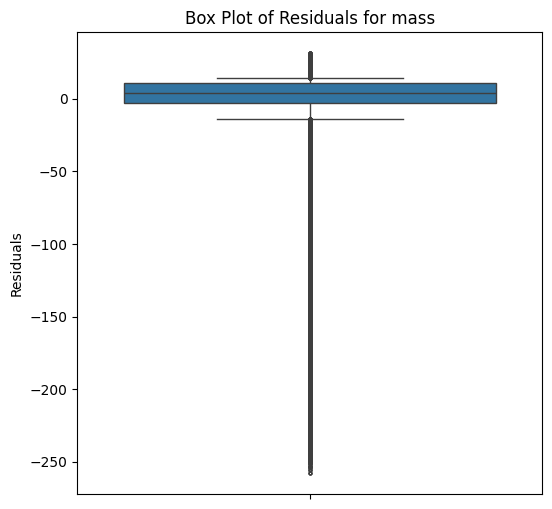

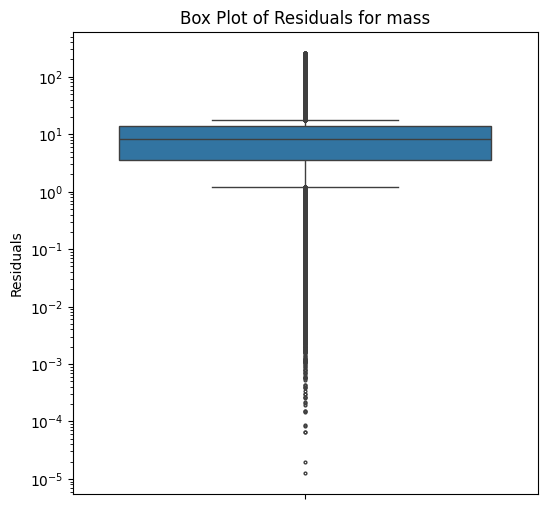

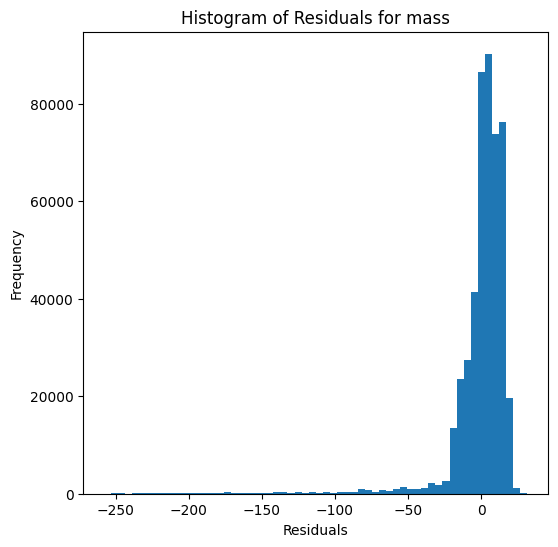

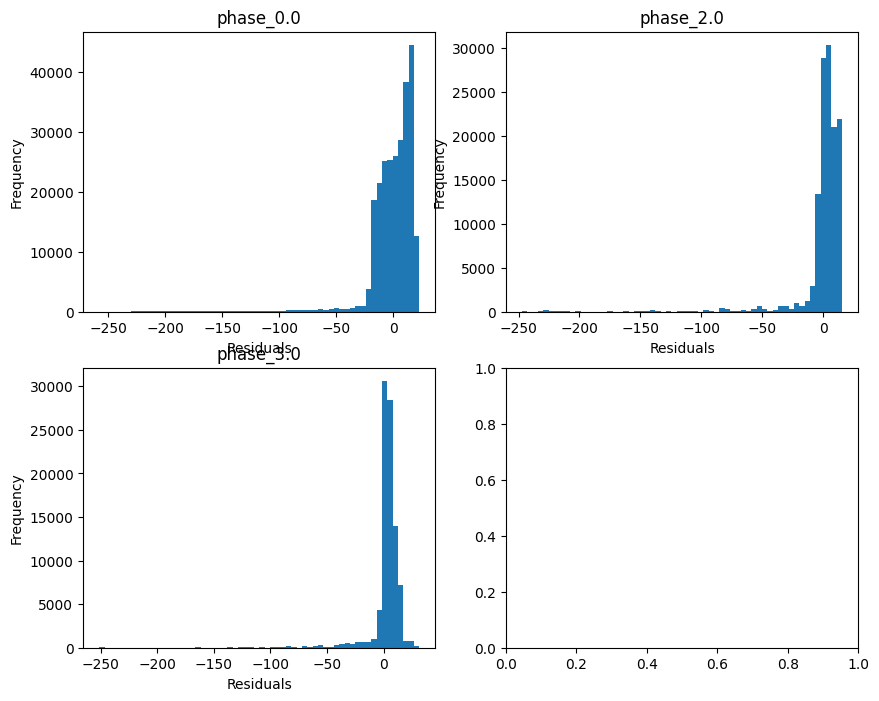

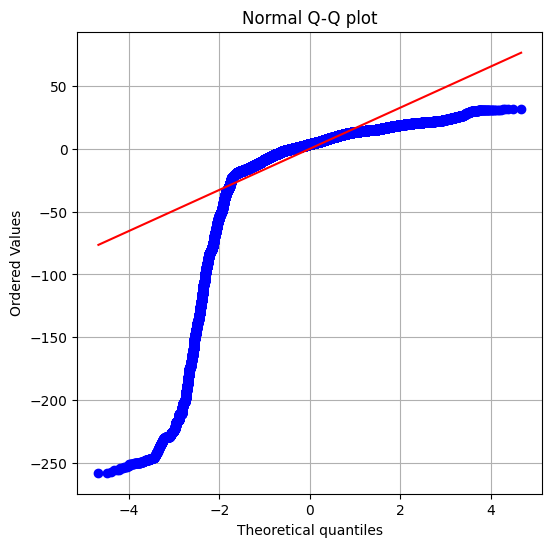

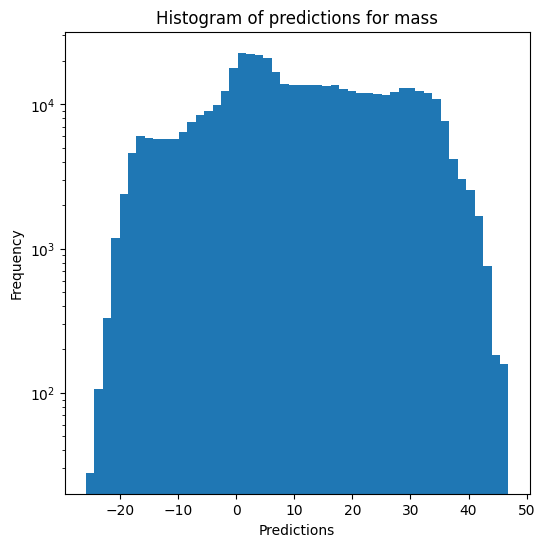

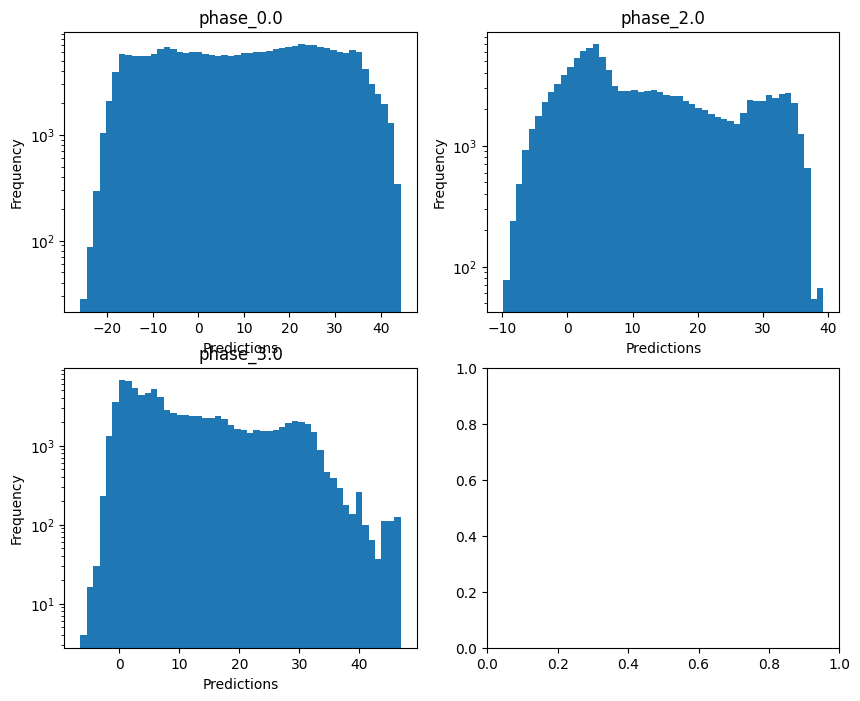

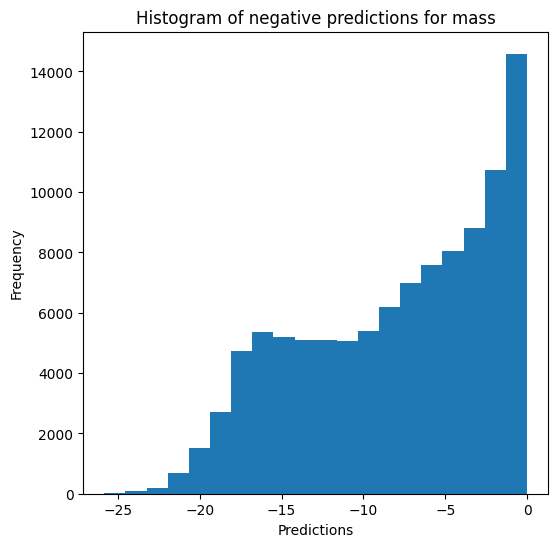

-1.861069007171269 - 3.1297545143214007

radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9755626571141772
  RMSE :  0.08920696455595324
  MAE :  0.06854991503547478
  MedAE :  0.05406571511091185
  CORR :  0.9877168815710867
  MAX_ER :  0.45880953343128383
  Percentiles : 
    75th percentile :  0.10192065658468273
    90th percentile :  0.14452683145985365
    95th percentile :  0.16854378002087703
    99th percentile :  0.260188662012309

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.900376516729969
  RVE :  0.969243149628593
  RMSE :  0.08713114427875067
  MAE :  0.055659137790087646
  MedAE :  0.029916386324884747
  CORR :  0.9845802131239262
  MAX_ER :  0.44653665980271207
  Percentiles : 
    75th percentile :  0.07152565865048846
    90th percentile :  0.14014106142582483
    95th percentile :  0.18773715099772725
    99th percentile :  0.35102376820

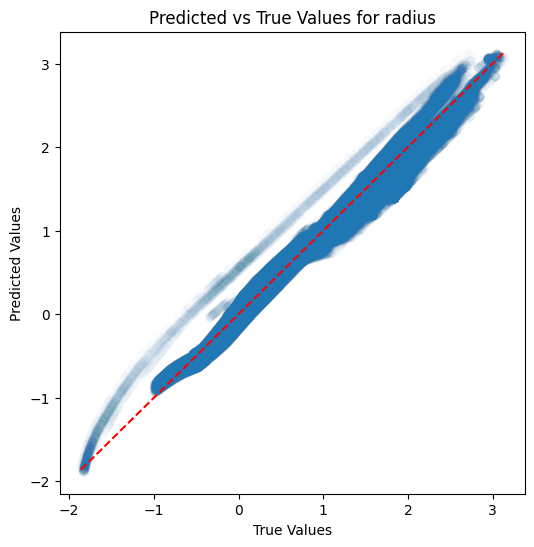

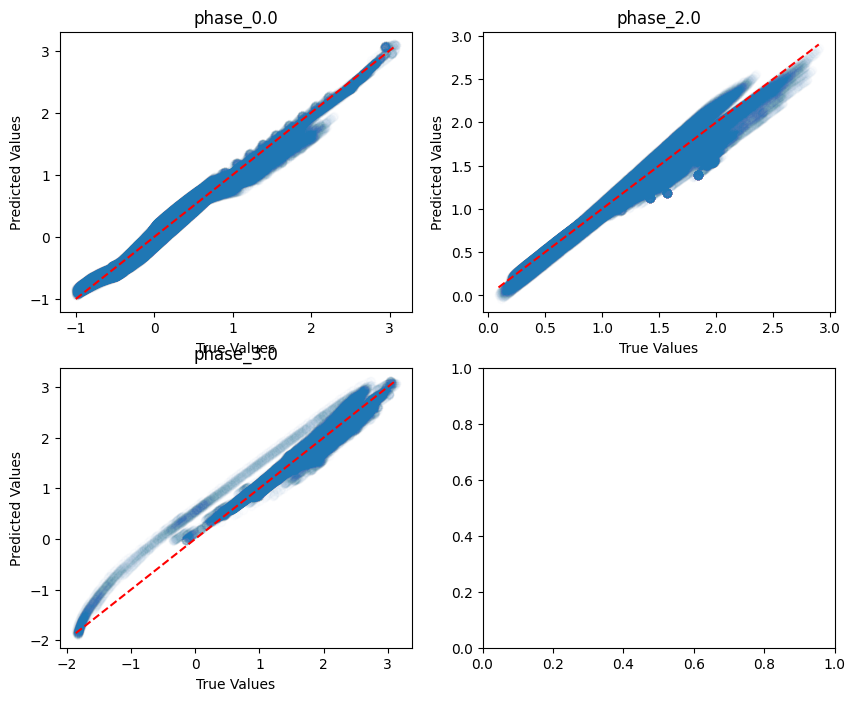

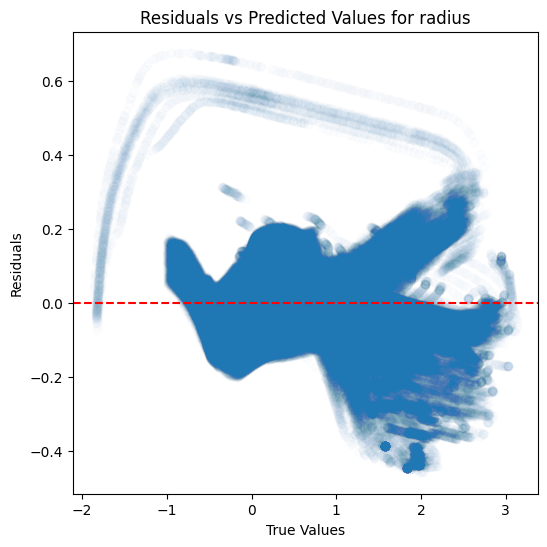

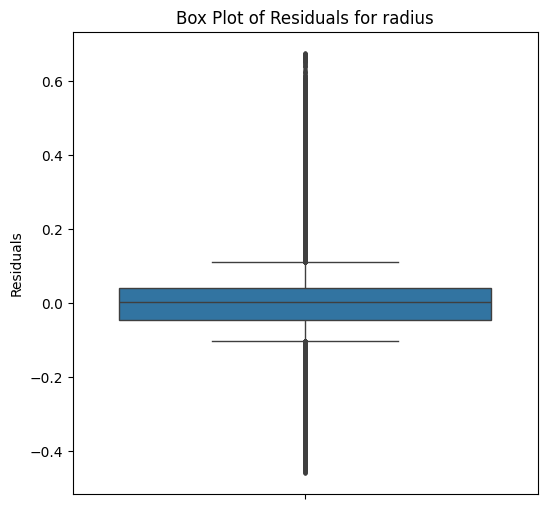

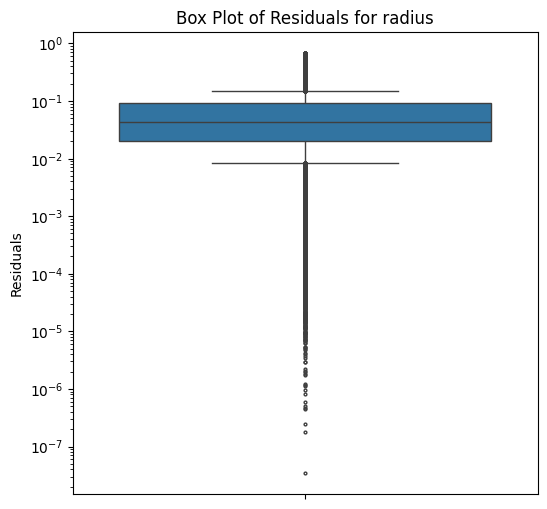

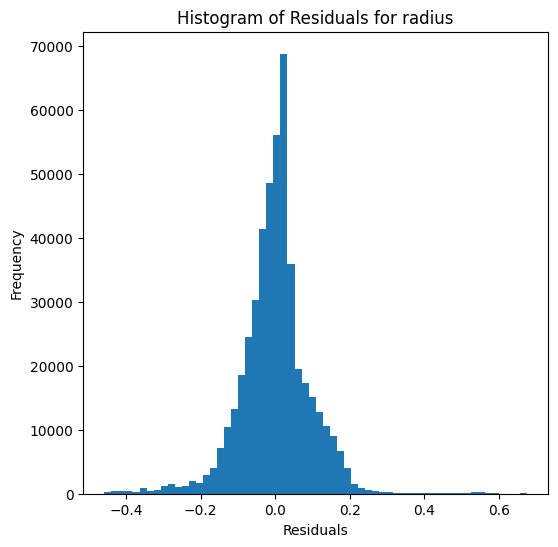

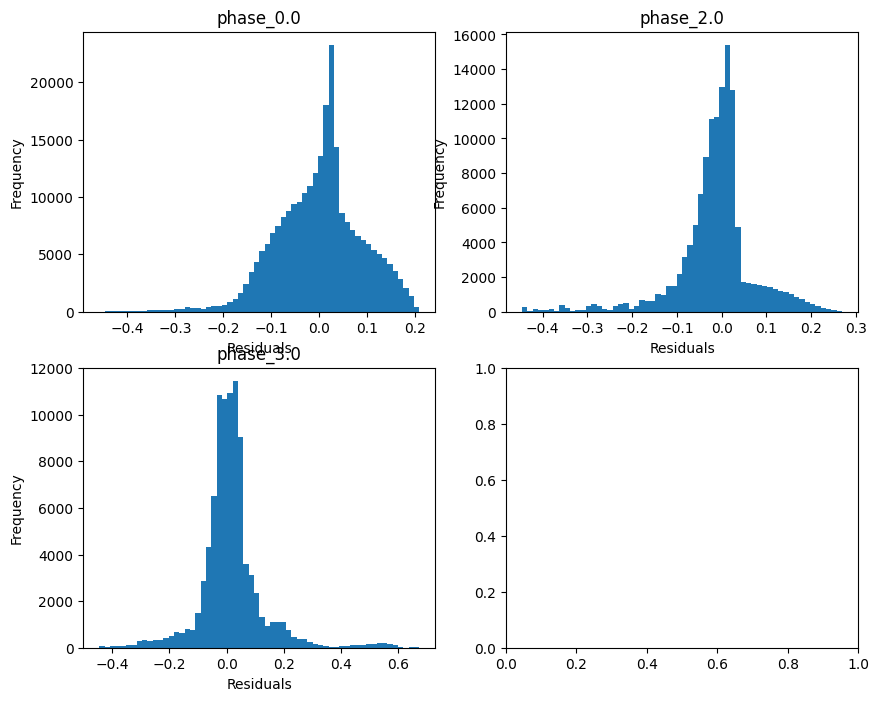

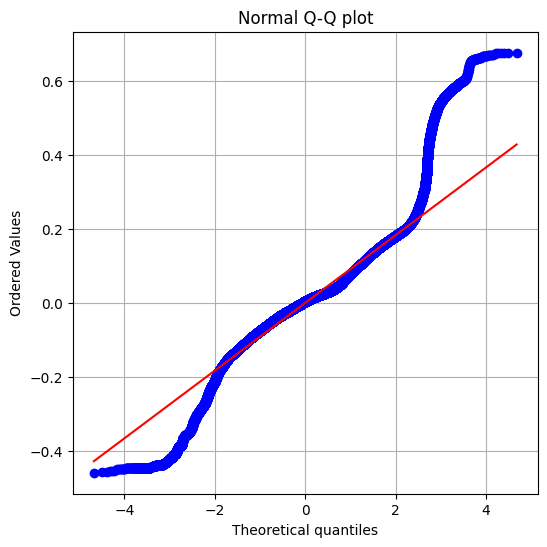

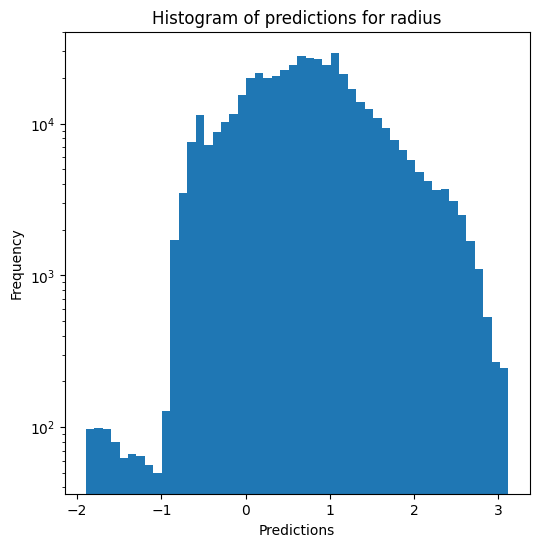

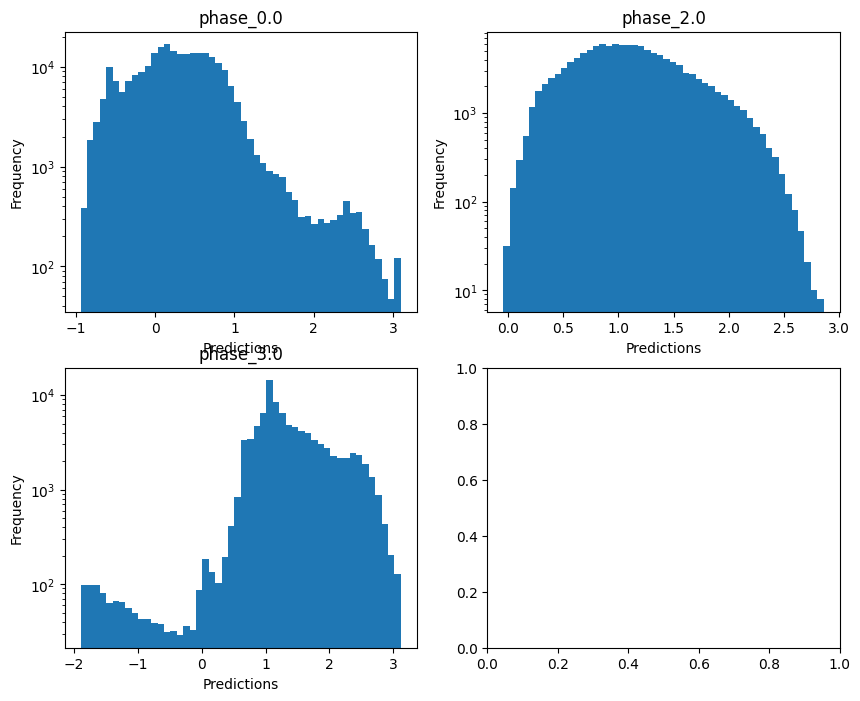

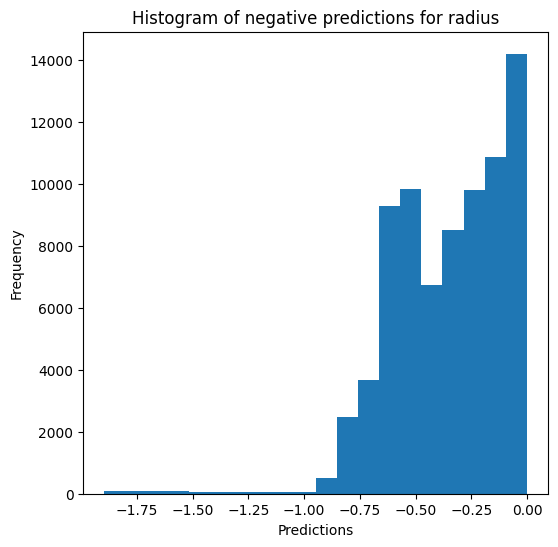

Saving results...


In [11]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True) #, override=True, use_preds=False

### Decision tree

In [28]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
0.0999979840073621 - 298.5447575808816
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9932104790132433
  RMSE :  2.1688602073160075
  MAE :  0.2732725838358024
  MedAE :  0.005943695672563365
  CORR :  0.9966147707166513
  MAX_ER :  109.57071657118573
  Percentiles : 
    75th percentile :  0.030765822163179912
    90th percentile :  0.18482534891487262
    95th percentile :  0.6690885009556999
    99th percentile :  5.817616445059914

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9990522246024206
  RMSE :  0.9083144316977759
  MAE :  0.06438382983348369
  MedAE :  0.00035957760645999315
  CORR :  0.9995261174866803
  MAX_ER :  107.5157166150316
  Percentiles : 
    75th percentile :  0.005485617235206408
    90th percenti

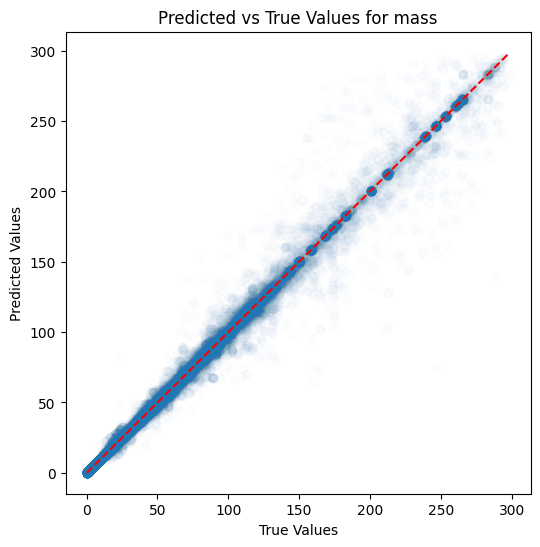

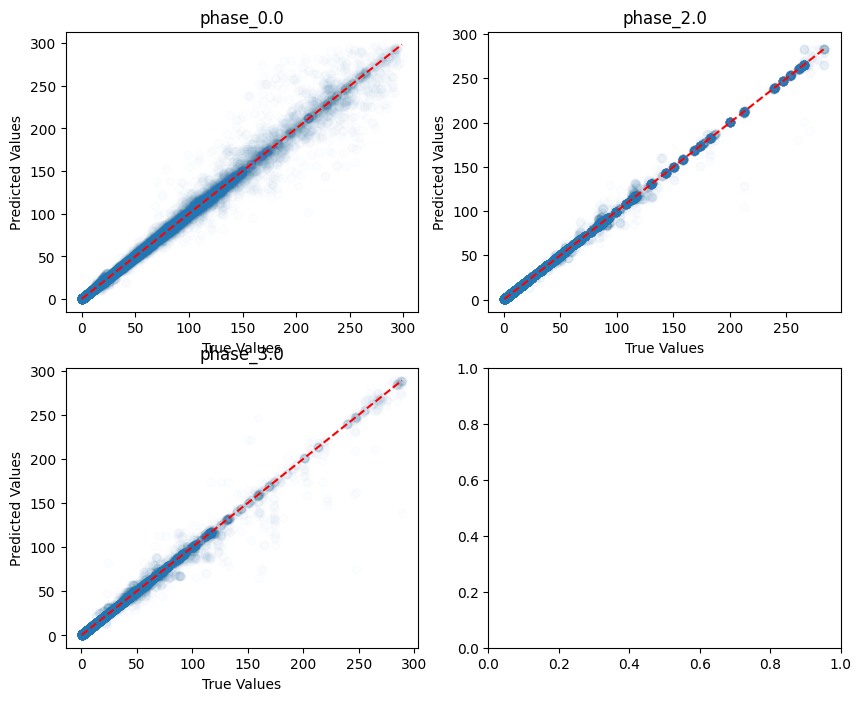

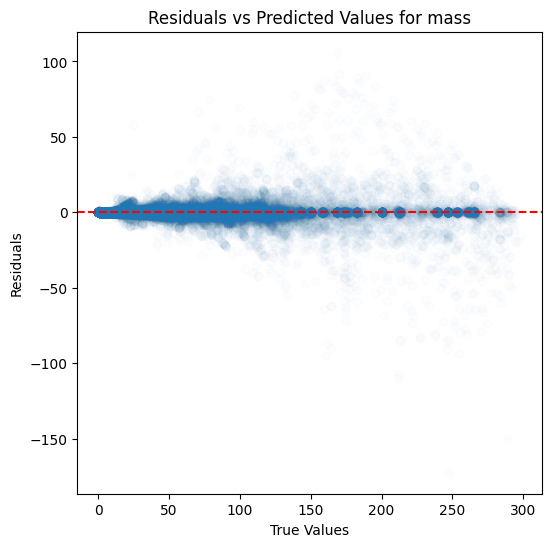

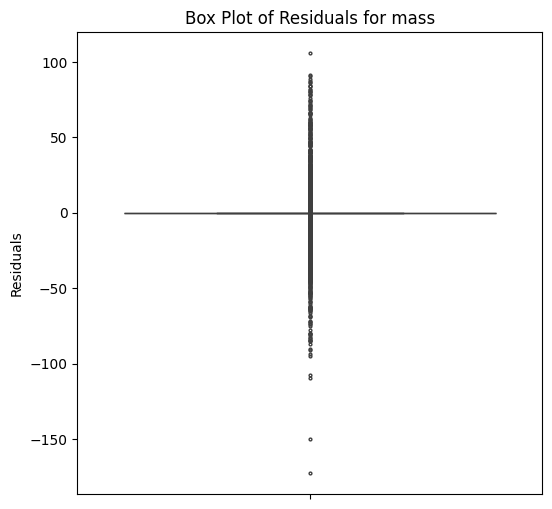

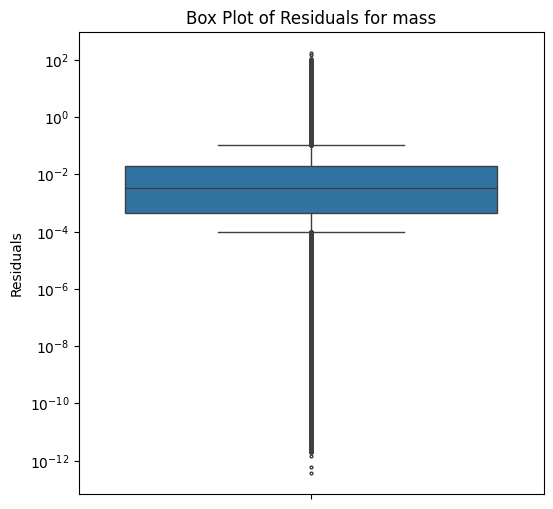

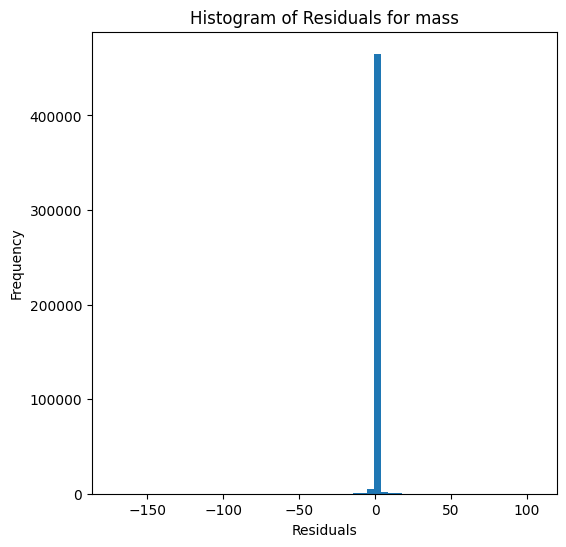

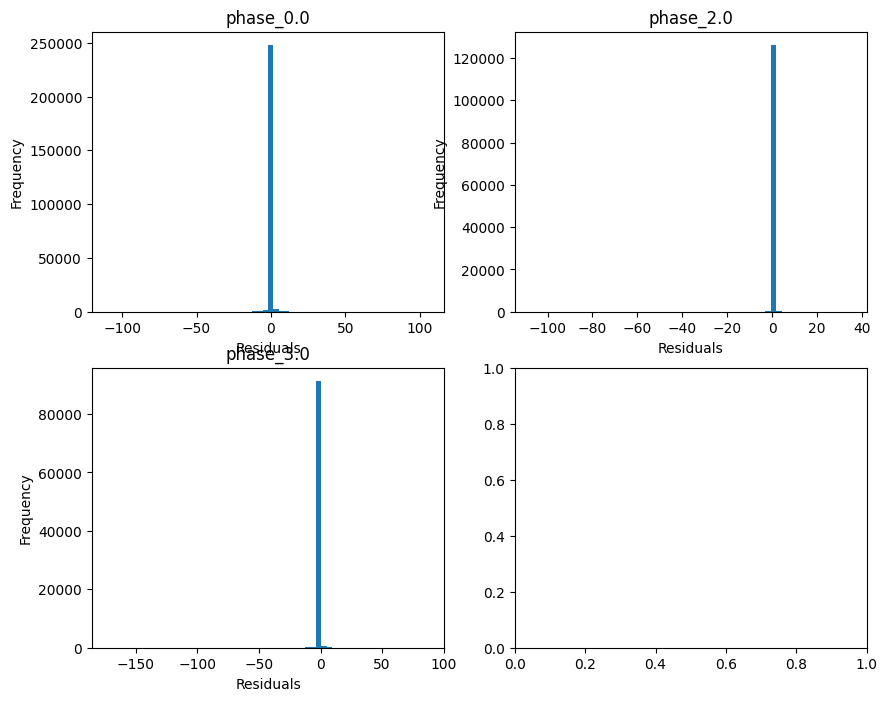

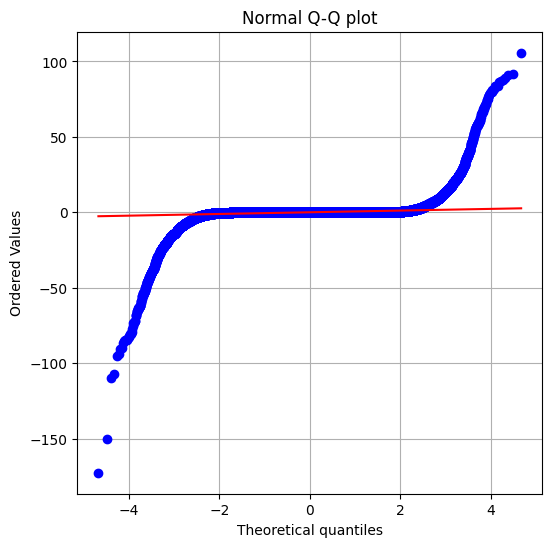

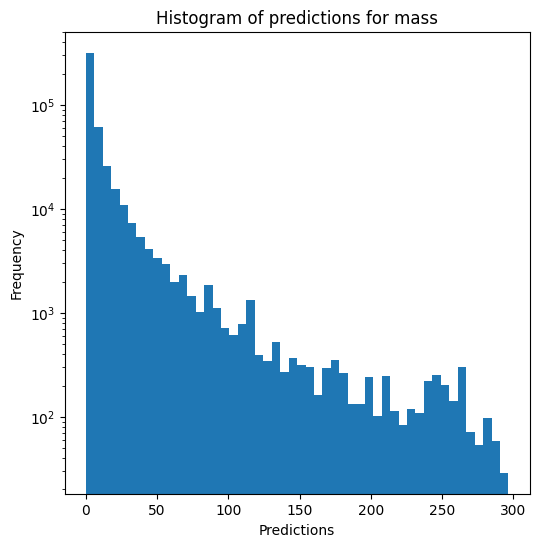

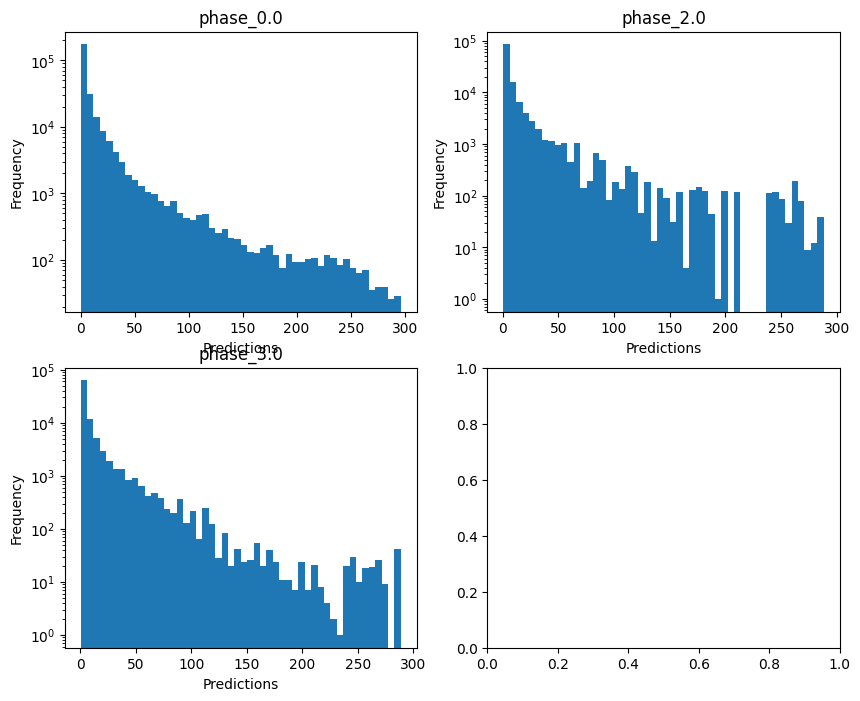

-1.861069007171269 - 3.1297545143214007

radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9997824748596408
  RMSE :  0.00841700495690241
  MAE :  0.004580194333593168
  MedAE :  0.002625897491966067
  CORR :  0.9998912748936138
  MAX_ER :  0.5064401538847425
  Percentiles : 
    75th percentile :  0.005319406110946834
    90th percentile :  0.010224046030667658
    95th percentile :  0.014937952100208663
    99th percentile :  0.03219525128447998

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.900376516729969
  RVE :  0.9995892806800809
  RMSE :  0.009965134447302801
  MAE :  0.006760991091182068
  MedAE :  0.005224201914791282
  CORR :  0.9997957313689314
  MAX_ER :  0.3051654040090013
  Percentiles : 
    75th percentile :  0.009084629130768795
    90th percentile :  0.01348720660211633
    95th percentile :  0.016678504971117725
    99th percentile :  0.03

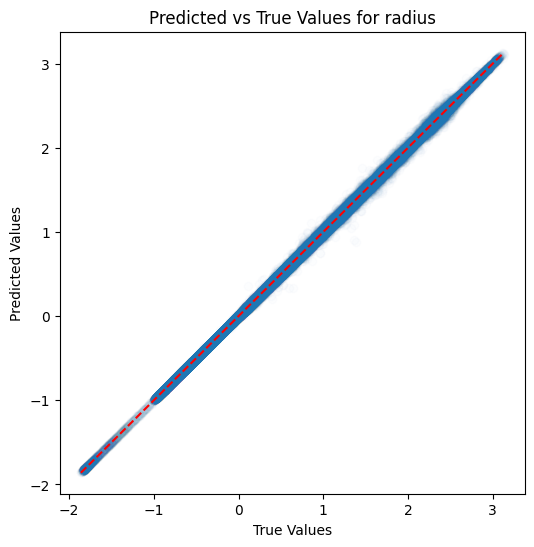

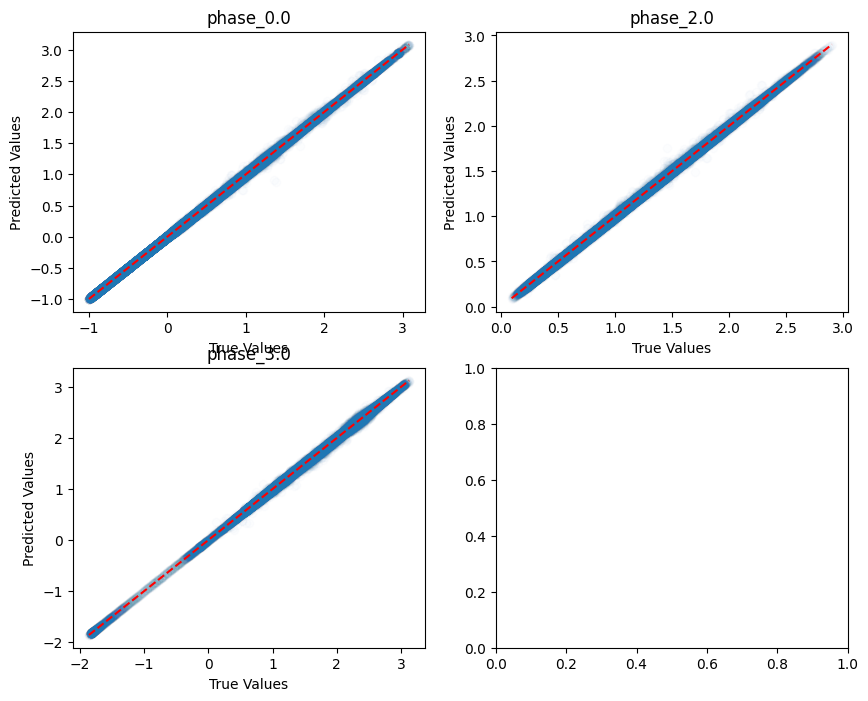

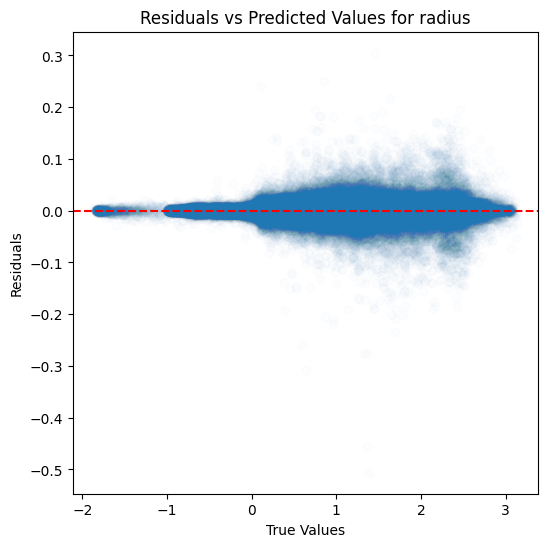

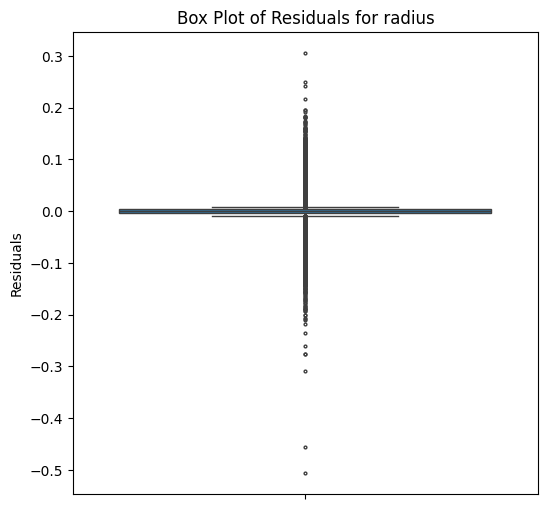

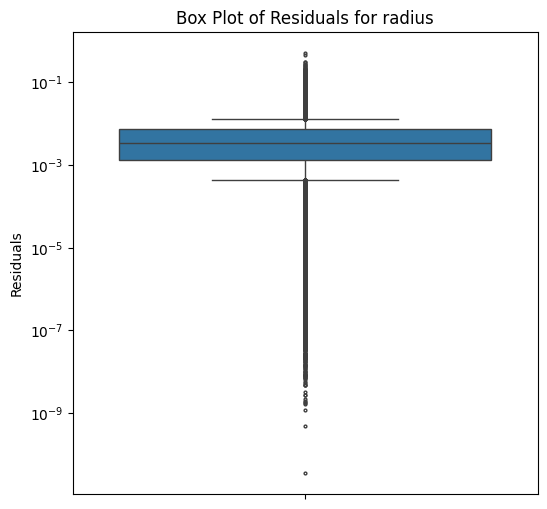

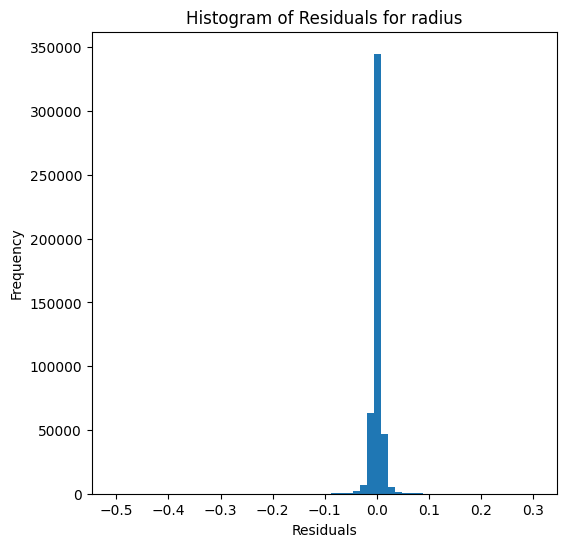

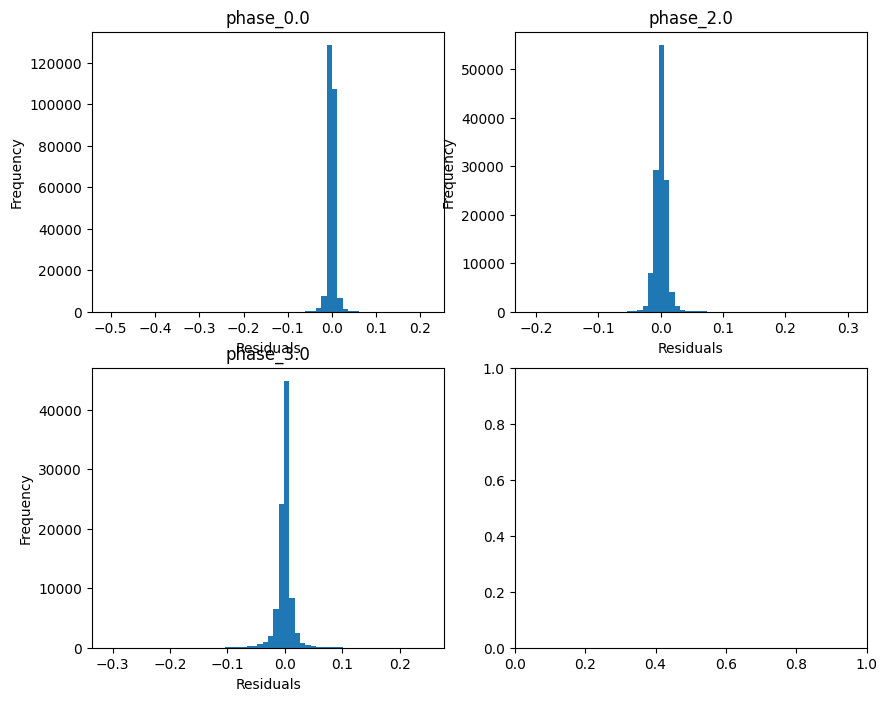

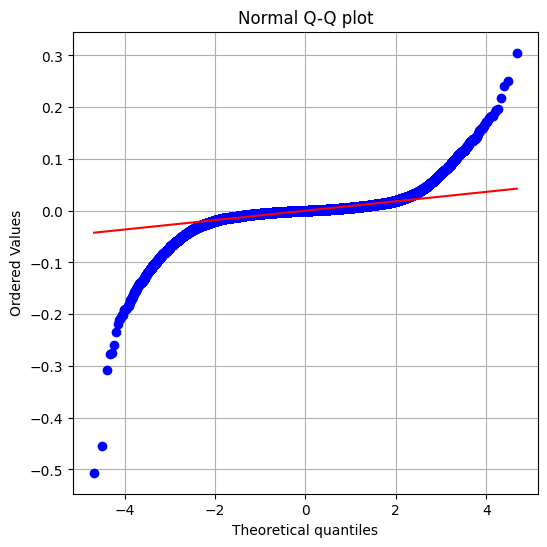

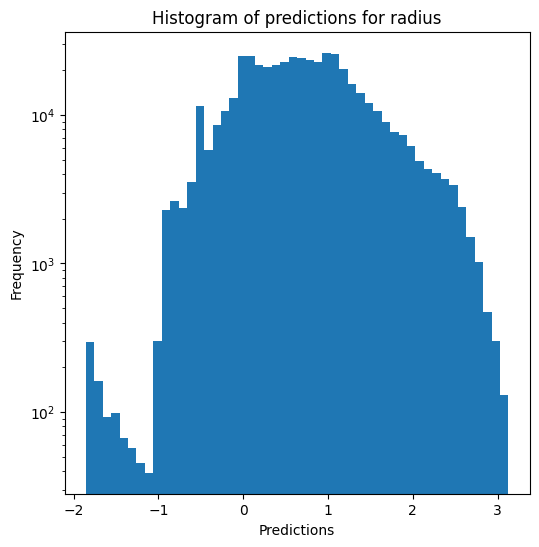

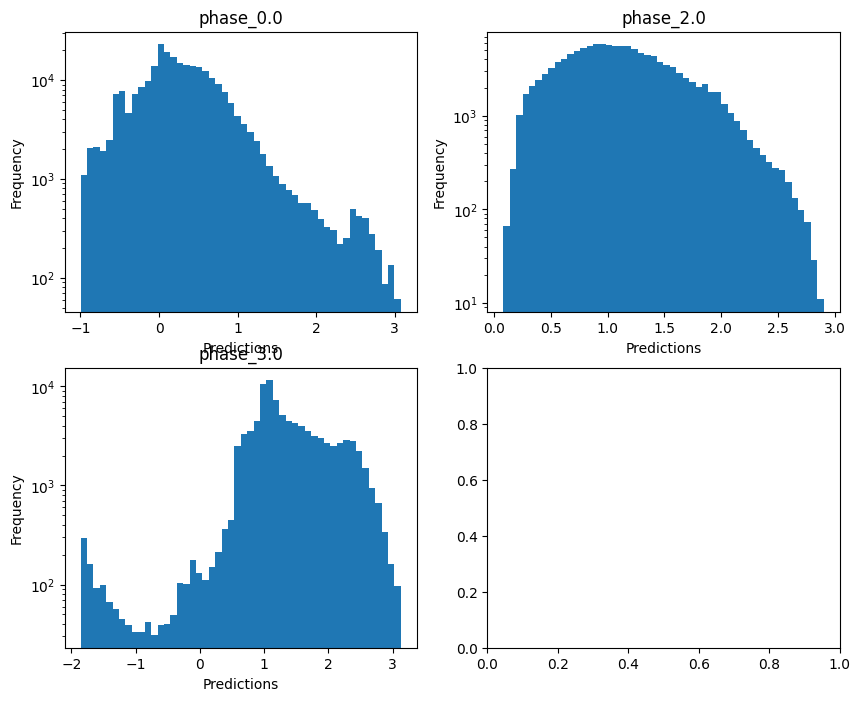

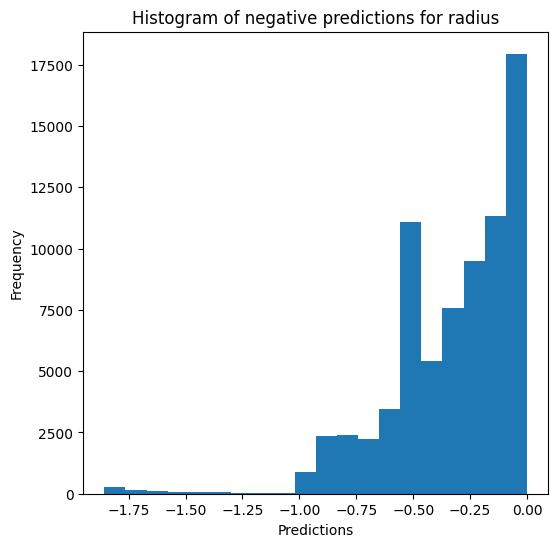

Saving predictions and results...


In [29]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True)

### K-nearest neighbours

In [20]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
0.0999979840073621 - 298.5447575808816
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9843532514329937
  RMSE :  3.2933564377767808
  MAE :  0.43075607459139603
  MedAE :  0.010325085038553894
  CORR :  0.9924016349528691
  MAX_ER :  131.32403919647123
  Percentiles : 
    75th percentile :  0.05182261753647843
    90th percentile :  0.334656983280121
    95th percentile :  1.0579923557188804
    99th percentile :  8.831927336359222

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9993643677447985
  RMSE :  0.7438585186841322
  MAE :  0.0953968893639732
  MedAE :  0.0037488626156877425
  CORR :  0.9996827752137699
  MAX_ER :  36.37880950476517
  Percentiles : 
    75th percentile :  0.01709214887001892
    90th percentile : 

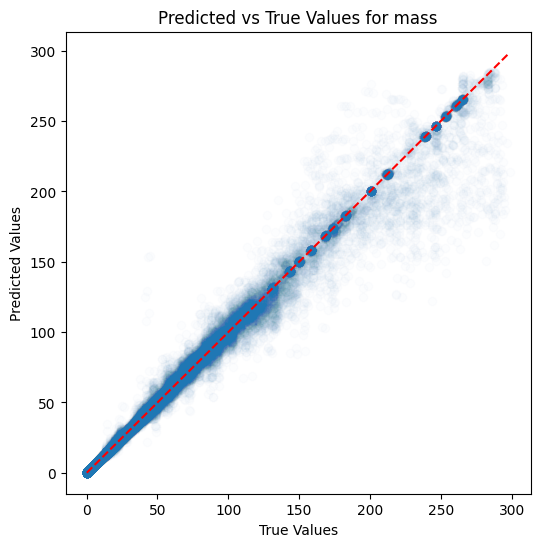

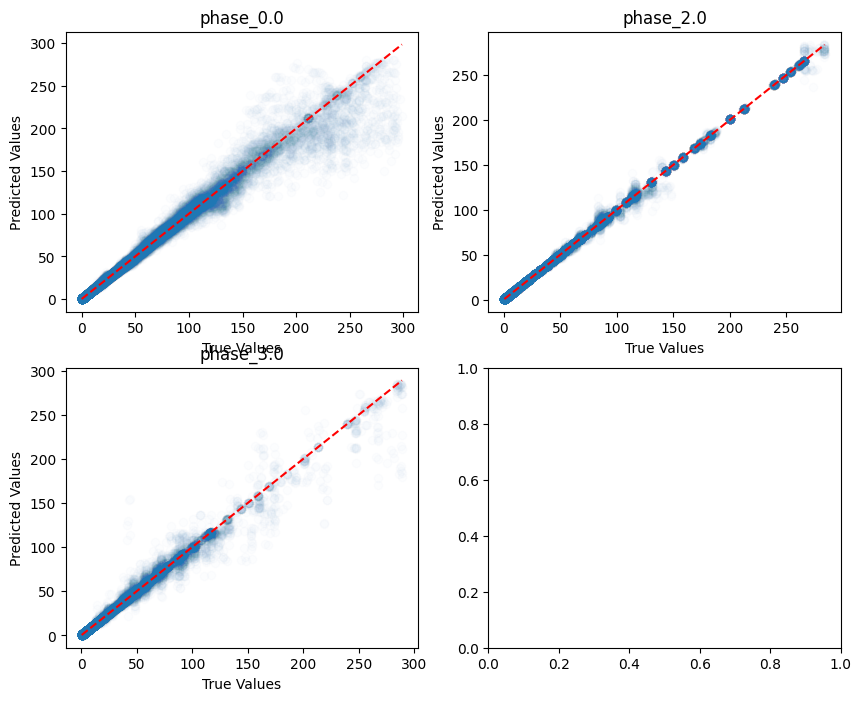

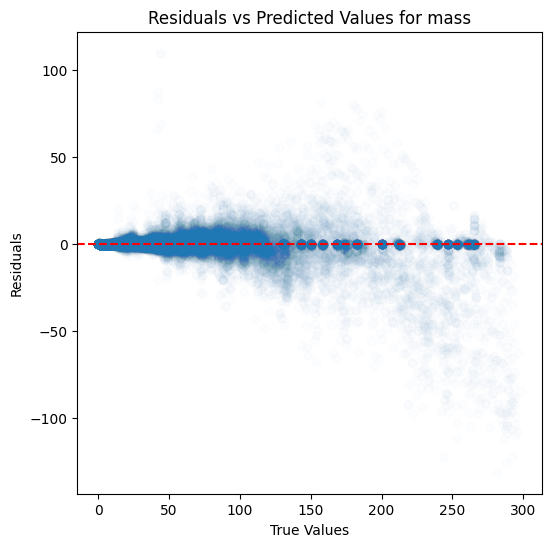

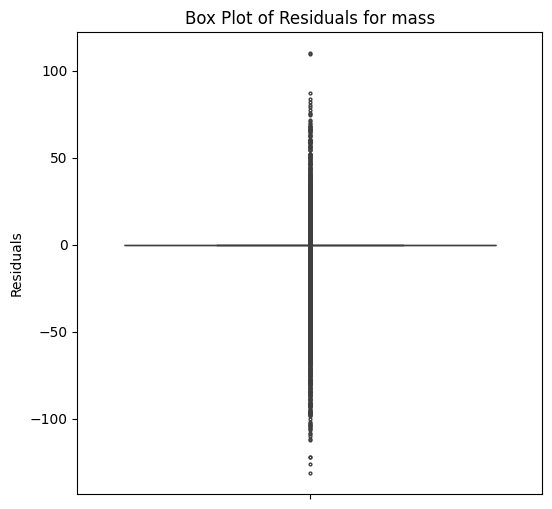

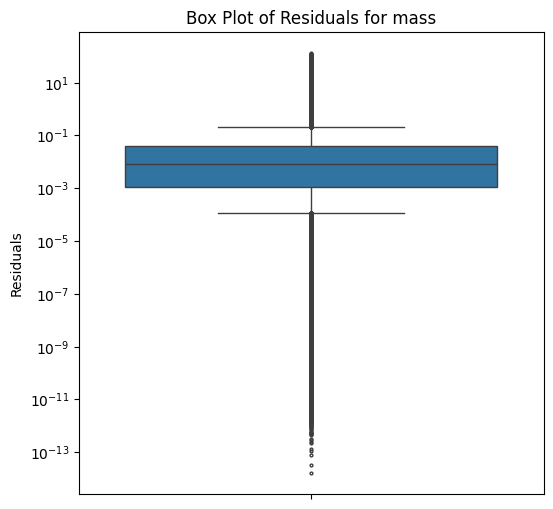

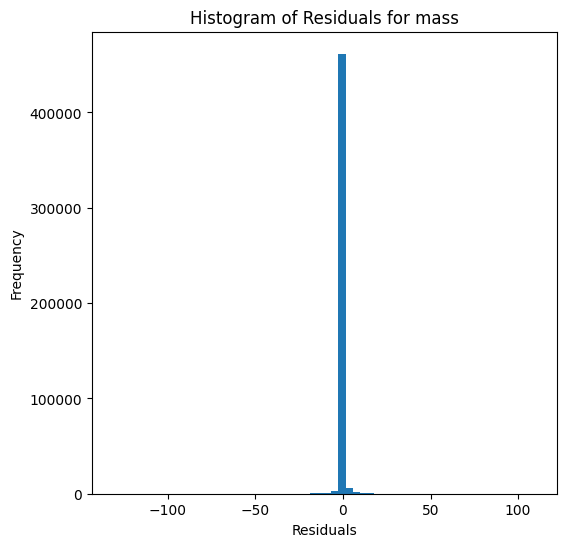

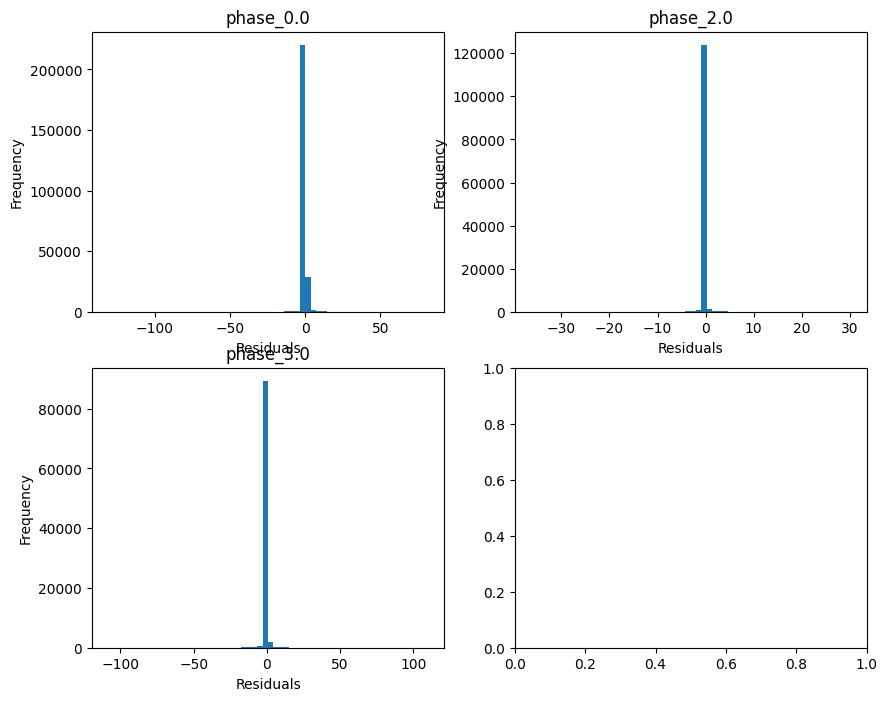

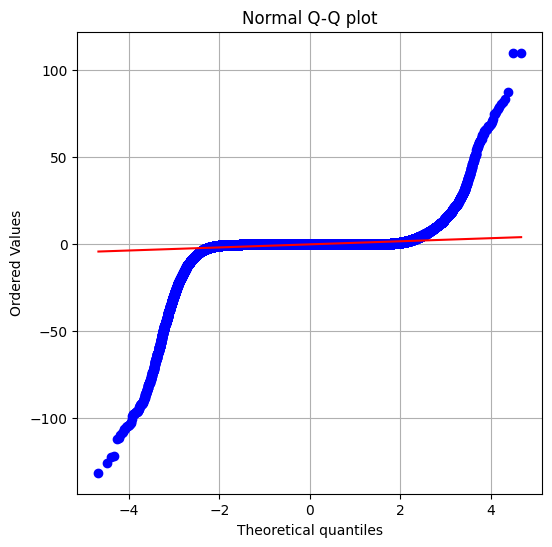

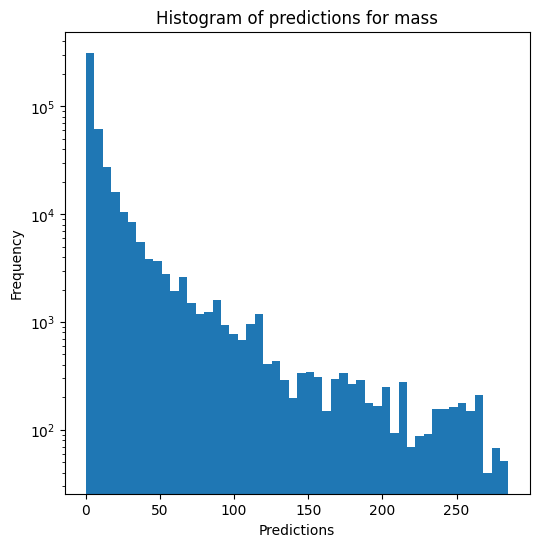

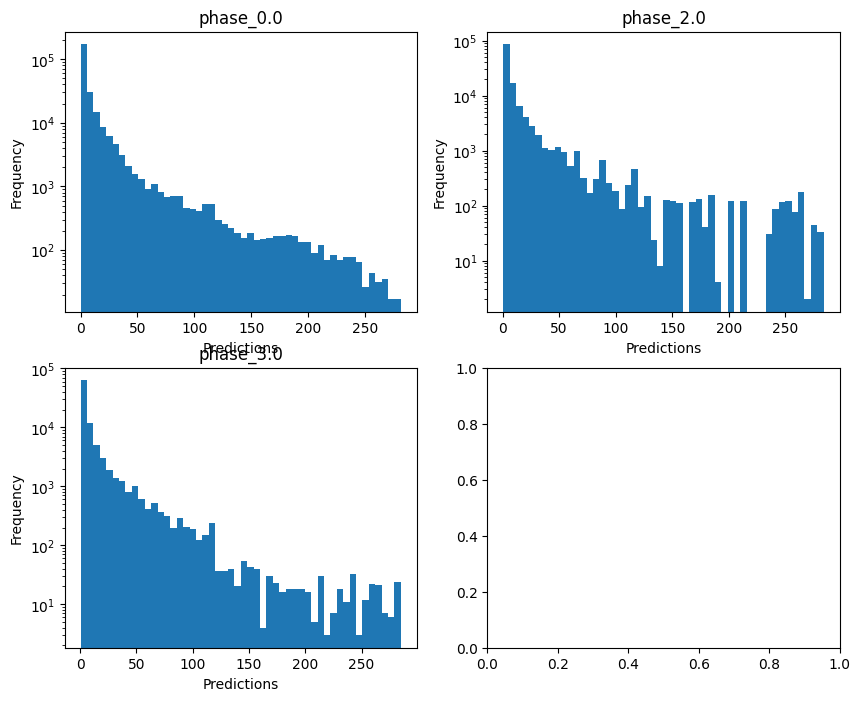

-1.861069007171269 - 3.1297545143214007

radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9998348784628862
  RMSE :  0.007333273235377103
  MAE :  0.004259044240868403
  MedAE :  0.0025843900660267316
  CORR :  0.9999177546784094
  MAX_ER :  0.1536142657637809
  Percentiles : 
    75th percentile :  0.005171312429509967
    90th percentile :  0.009539094240715917
    95th percentile :  0.013541155406567718
    99th percentile :  0.026397458825399046

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.900376516729969
  RVE :  0.9999061973615614
  RMSE :  0.004759543963379831
  MAE :  0.003450214237514526
  MedAE :  0.0025531746141193024
  CORR :  0.9999530987775218
  MAX_ER :  0.07185439050078646
  Percentiles : 
    75th percentile :  0.004679170375892022
    90th percentile :  0.007685429134612454
    95th percentile :  0.009729220513109982
    99th percentile :

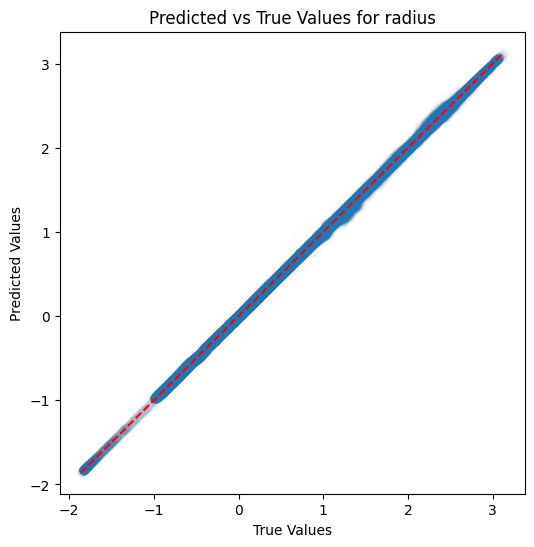

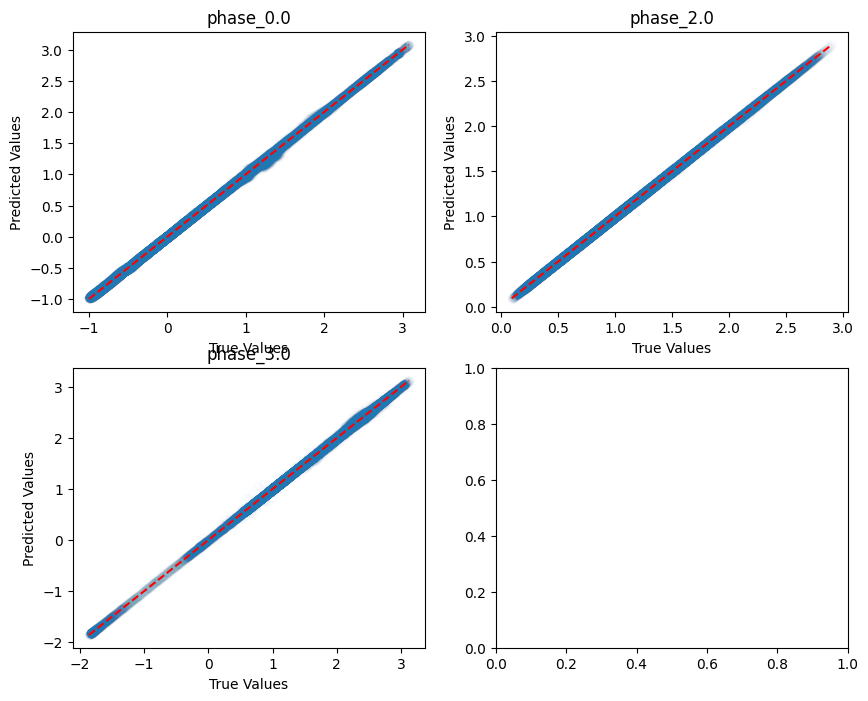

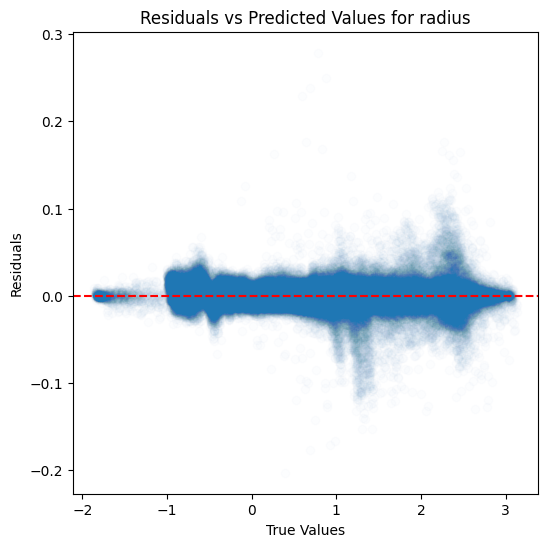

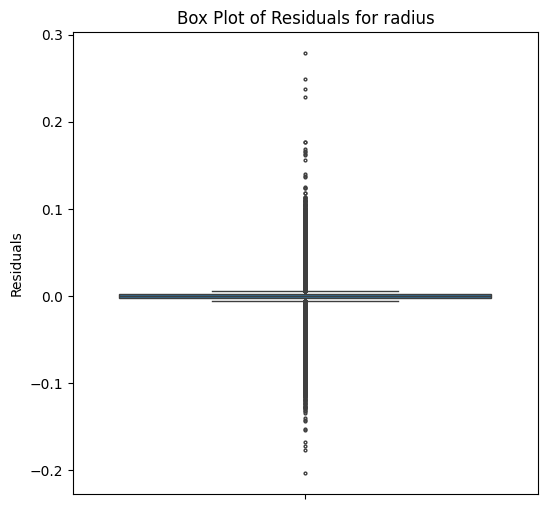

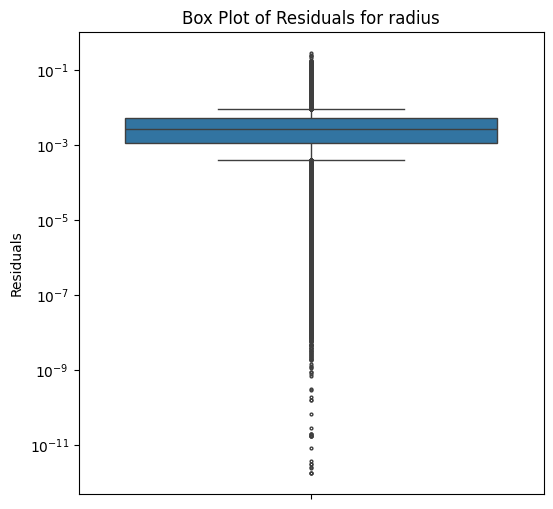

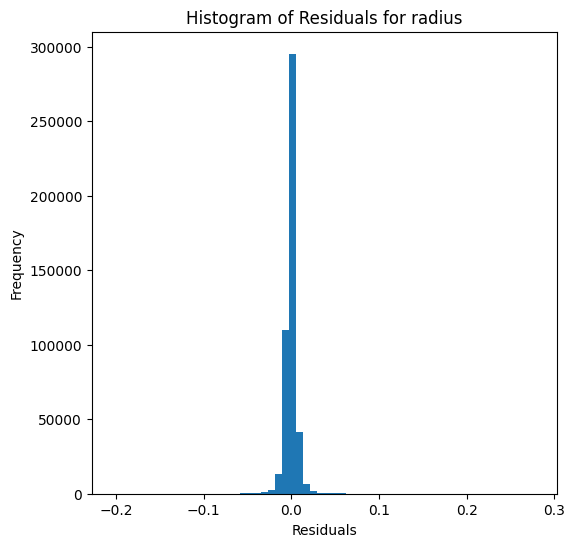

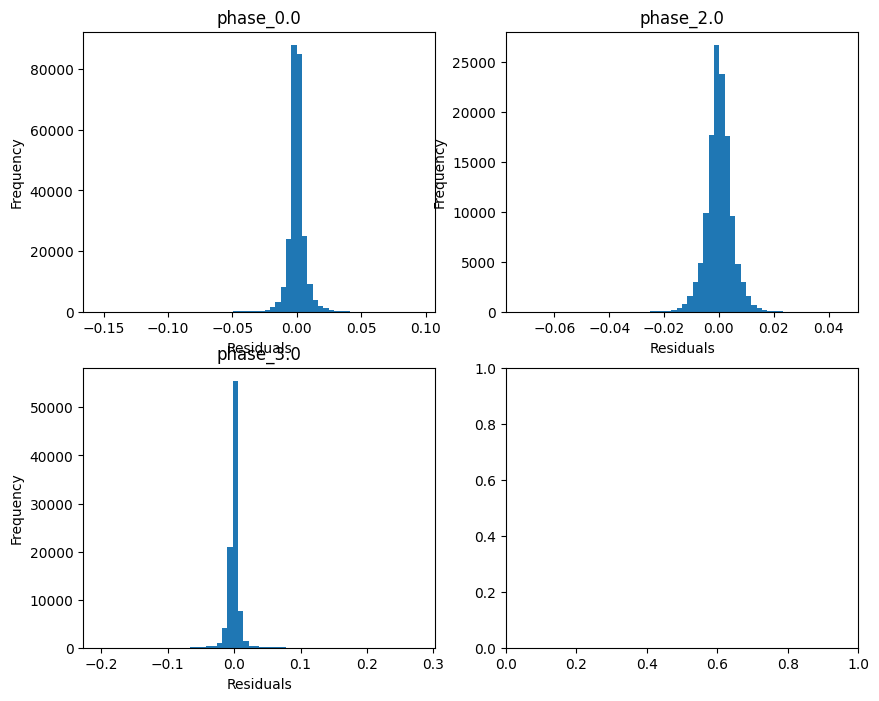

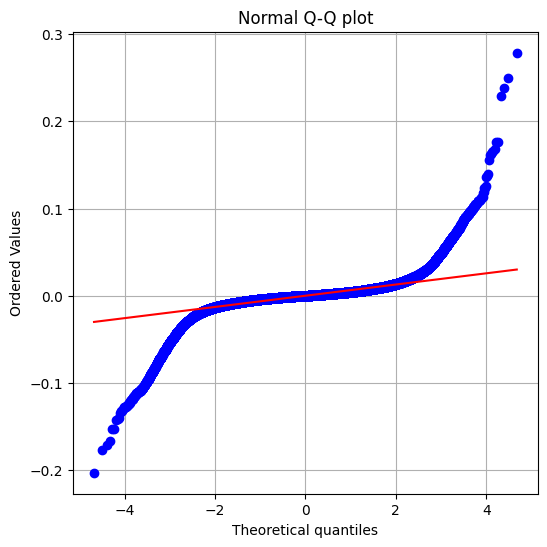

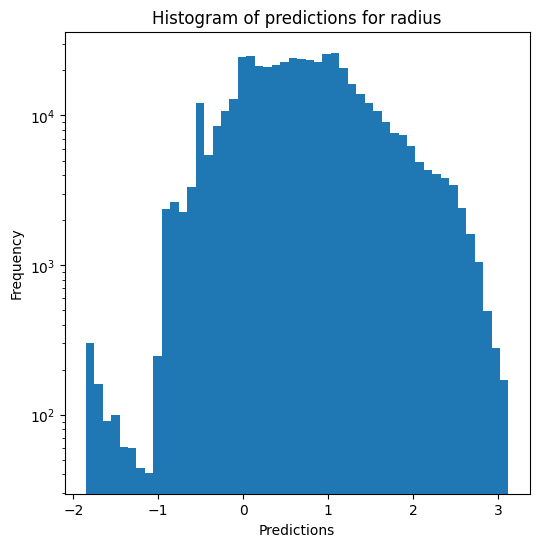

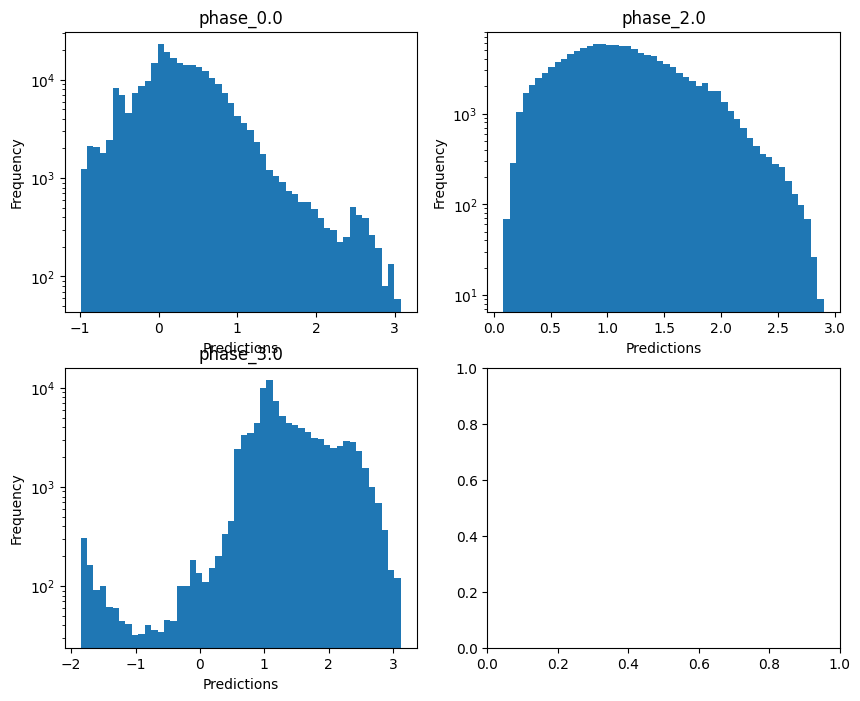

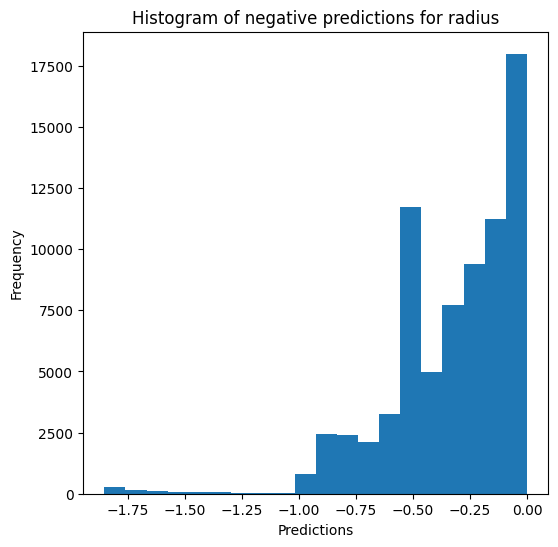

Saving predictions and results...


In [21]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True)

### Random forests

In [22]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
0.0999979840073621 - 298.5447575808816
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9973701575647923
  RMSE :  1.3500583861016149
  MAE :  0.1668845249667957
  MedAE :  0.0035245844935283266
  CORR :  0.9986864720298209
  MAX_ER :  81.84956024071585
  Percentiles : 
    75th percentile :  0.01627728511101445
    90th percentile :  0.10558785145524692
    95th percentile :  0.4116874624553459
    99th percentile :  3.56452519003893

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9997183172334847
  RMSE :  0.49521348532075204
  MAE :  0.0599030750965042
  MedAE :  0.004074590562352043
  CORR :  0.9998599232997458
  MAX_ER :  21.540837093607237
  Percentiles : 
    75th percentile :  0.010635528024326157
    90th percentile 

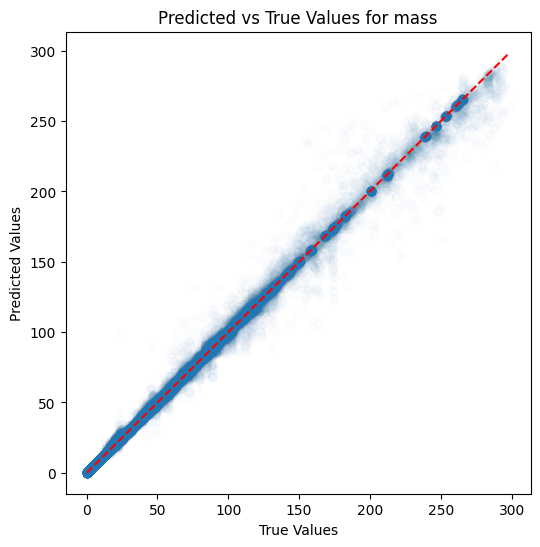

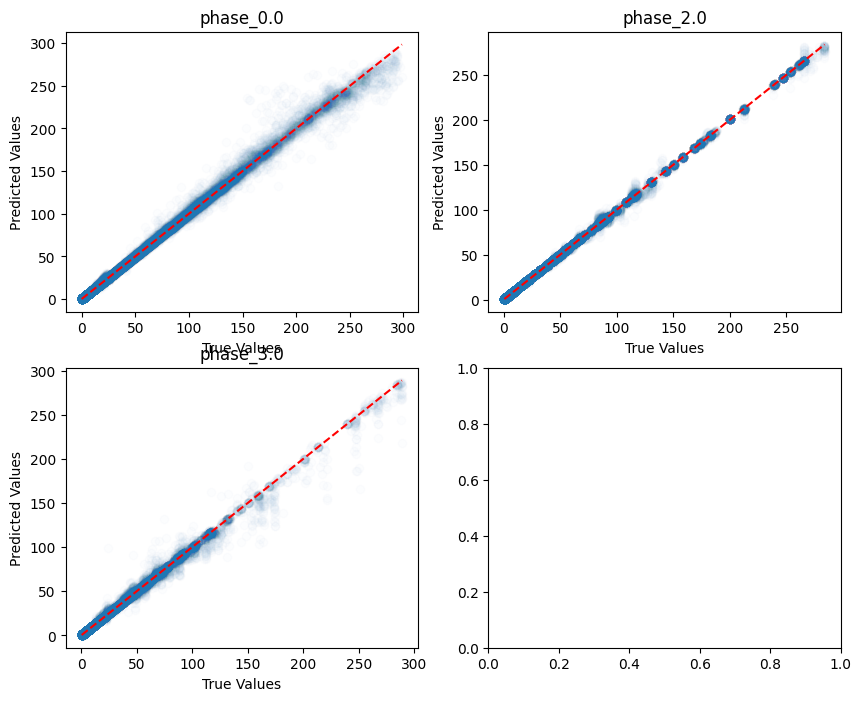

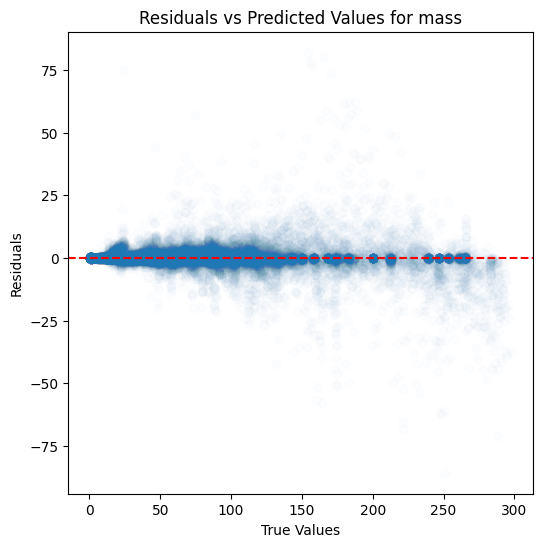

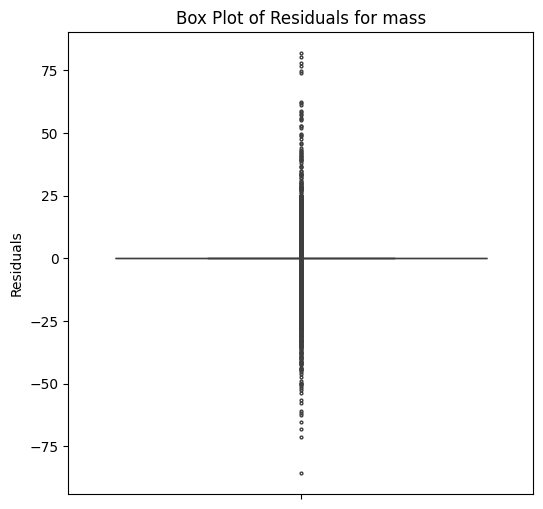

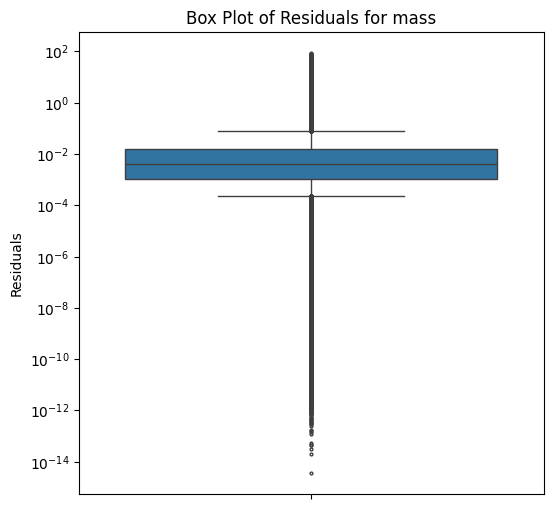

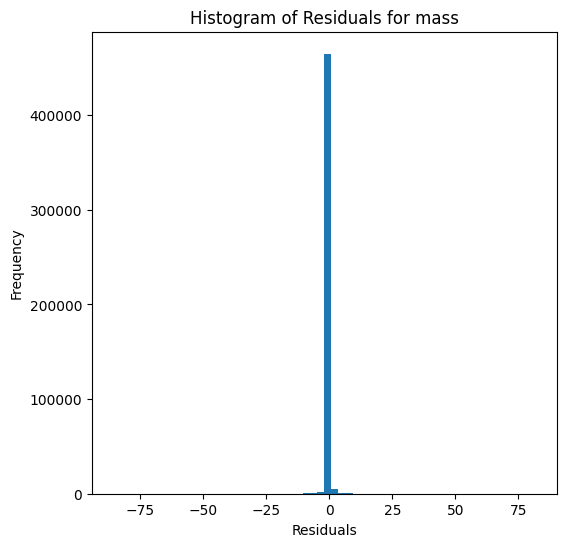

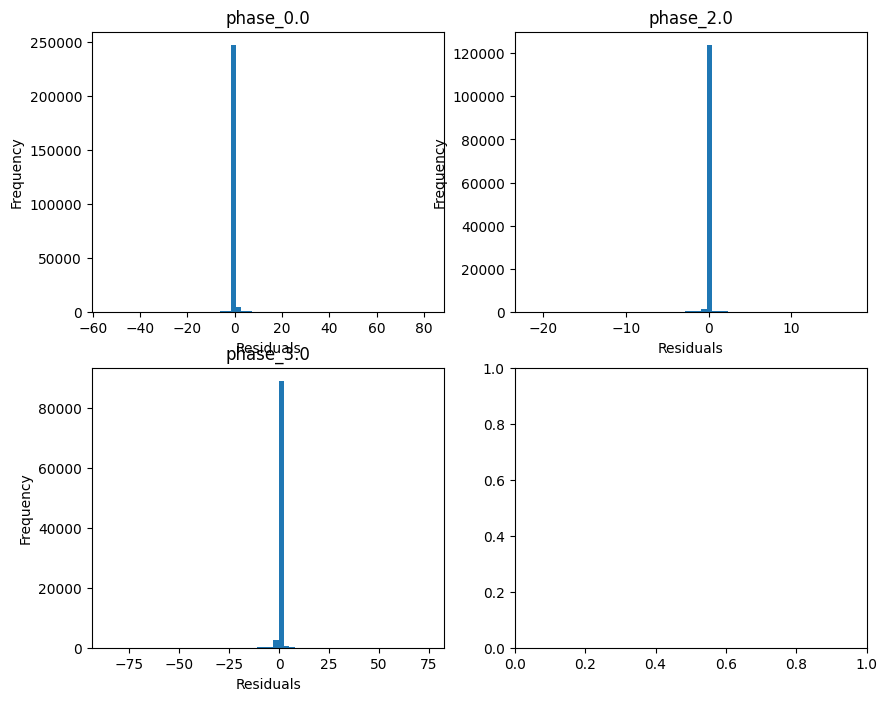

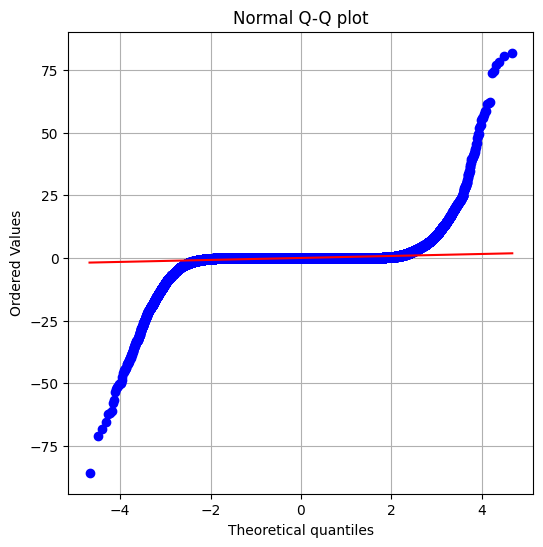

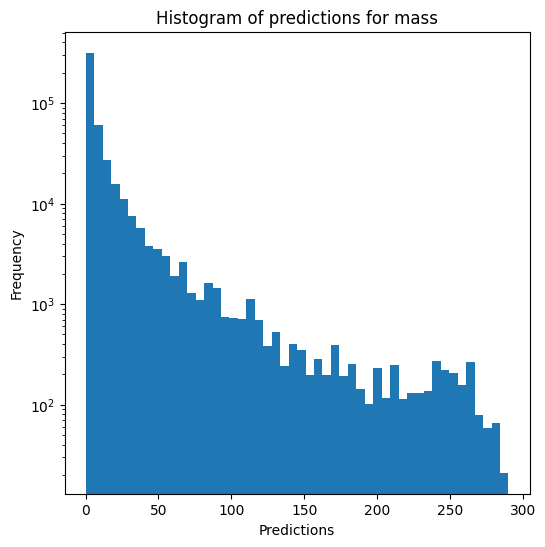

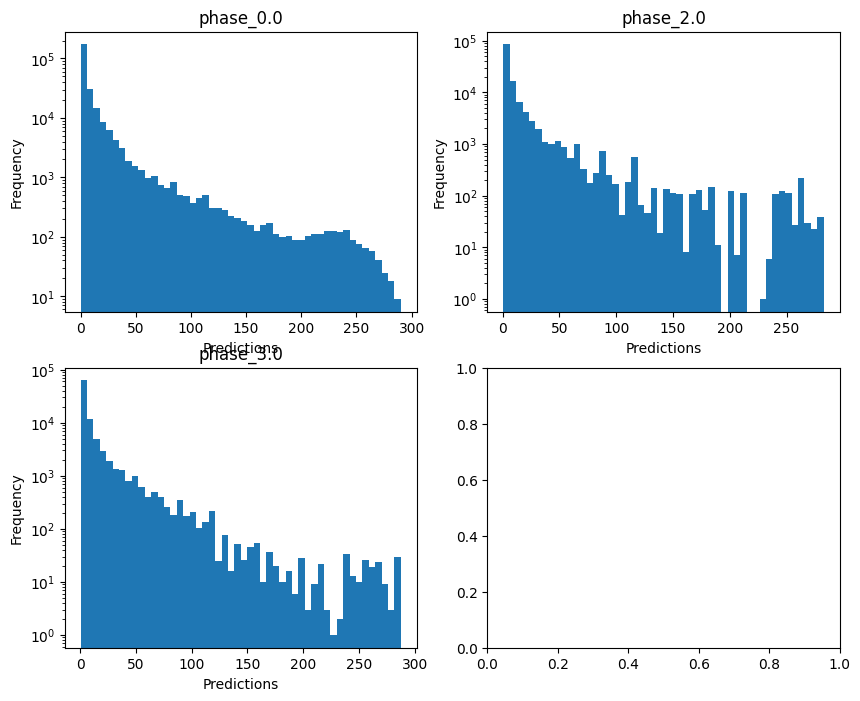

-1.861069007171269 - 3.1297545143214007

radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.999948388627212
  RMSE :  0.004099759822083538
  MAE :  0.002070584540408149
  MedAE :  0.0010098834104920185
  CORR :  0.9999742397308428
  MAX_ER :  0.1991549603986349
  Percentiles : 
    75th percentile :  0.002324173819403308
    90th percentile :  0.0048207233361919465
    95th percentile :  0.007399513225224402
    99th percentile :  0.01642755532848735

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.900376516729969
  RVE :  0.9999322817533202
  RMSE :  0.0040747771955782575
  MAE :  0.002694836316878708
  MedAE :  0.0017591556092366734
  CORR :  0.9999668230698375
  MAX_ER :  0.07107360425912734
  Percentiles : 
    75th percentile :  0.003610842025439903
    90th percentile :  0.0061825512375139335
    95th percentile :  0.008272401310084054
    99th percentile 

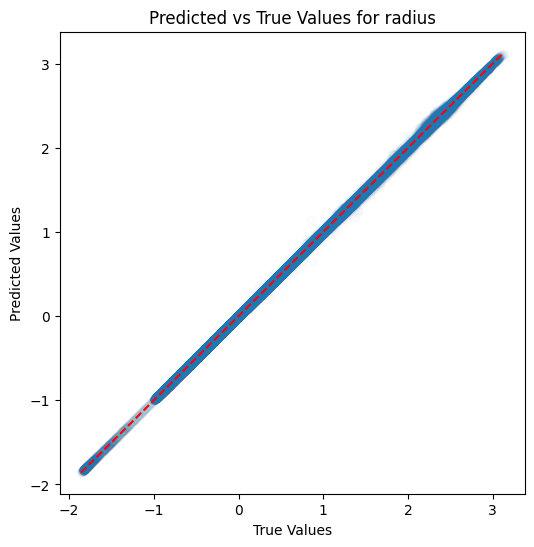

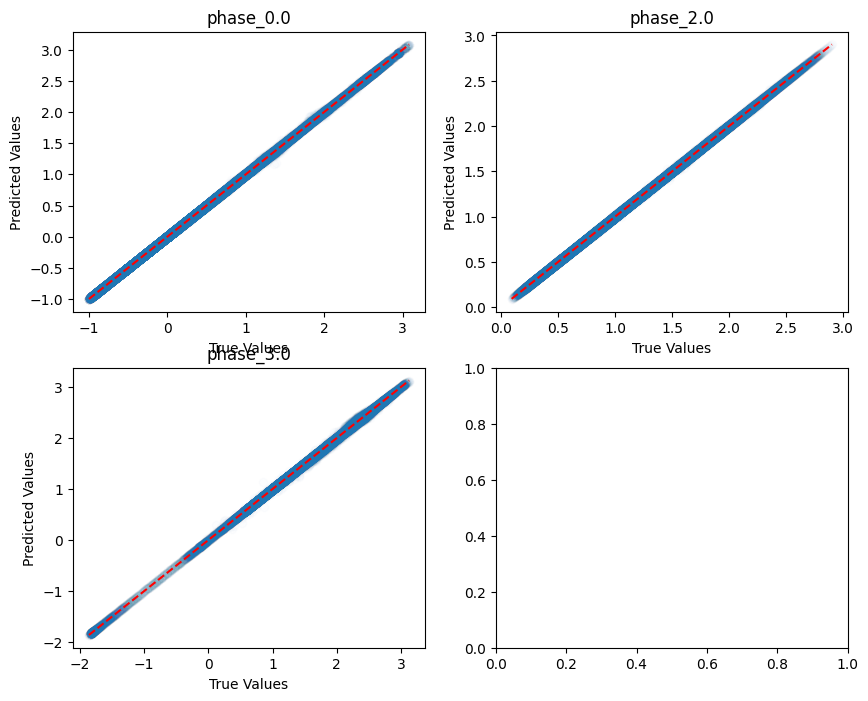

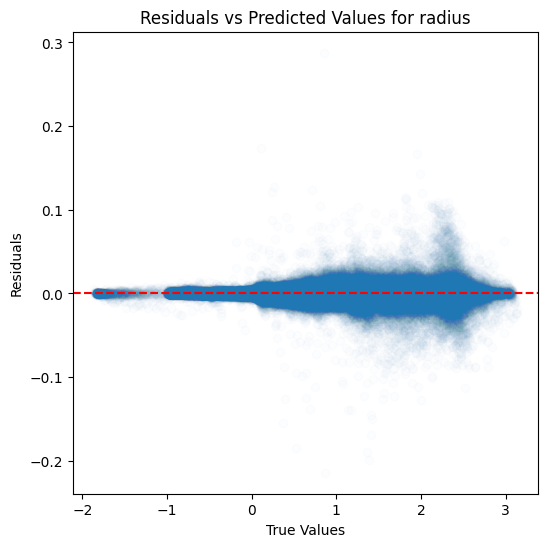

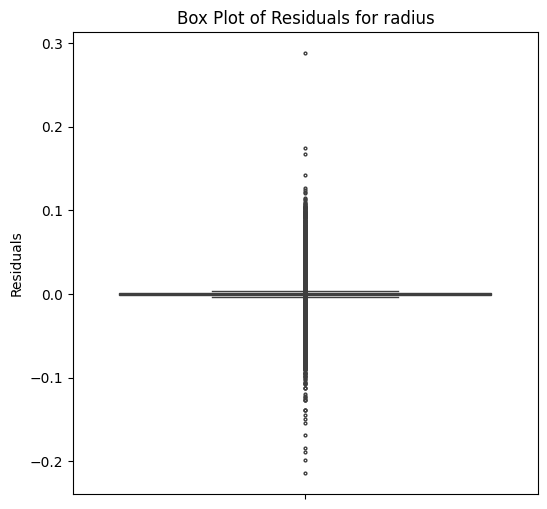

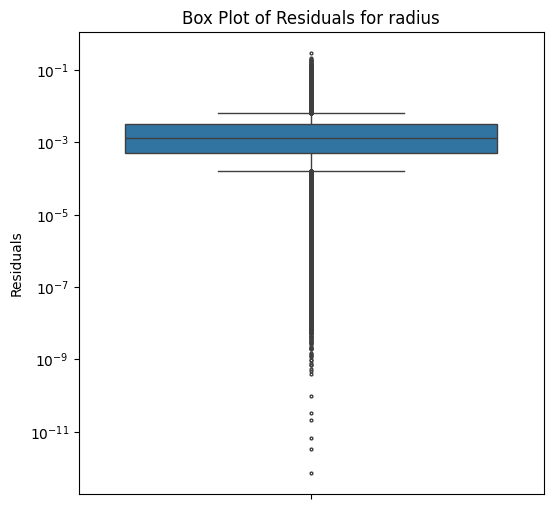

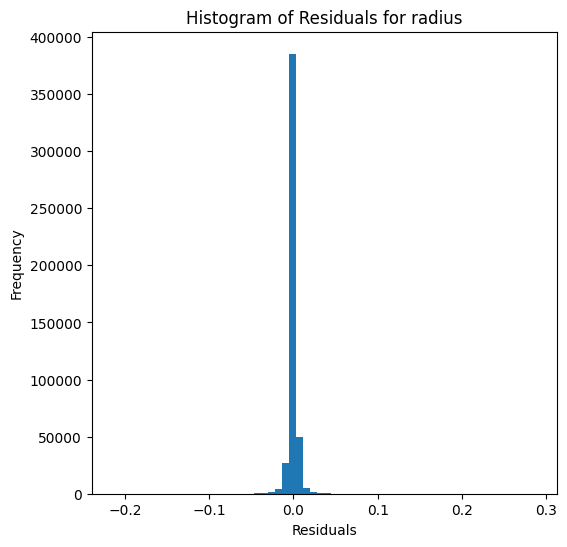

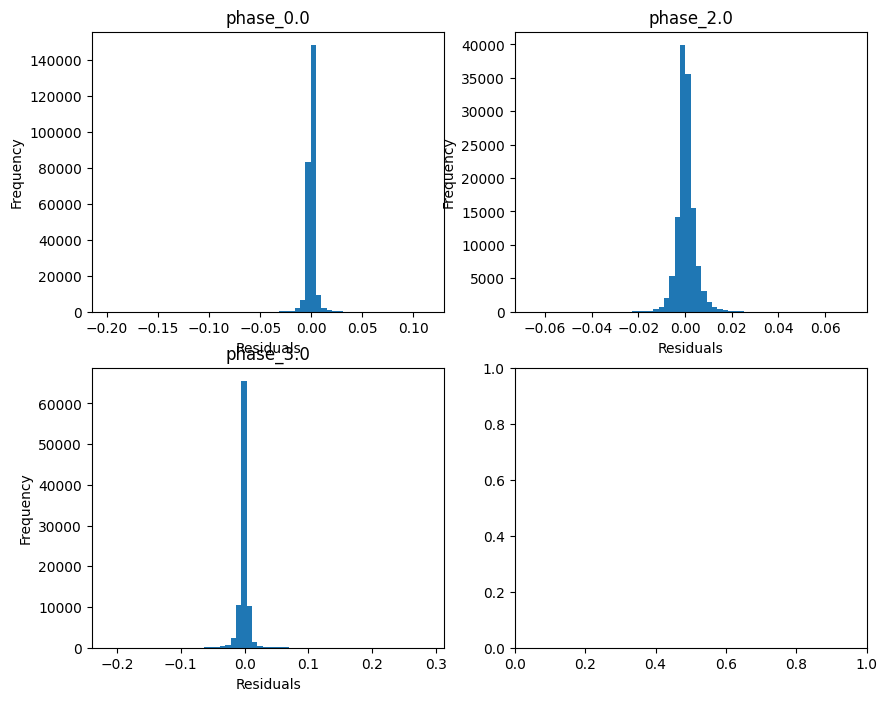

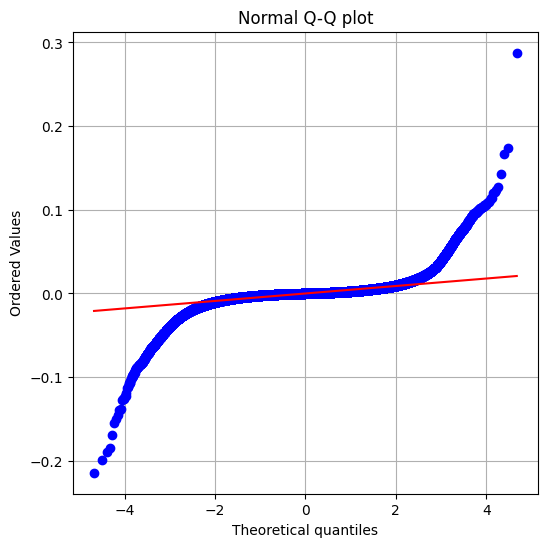

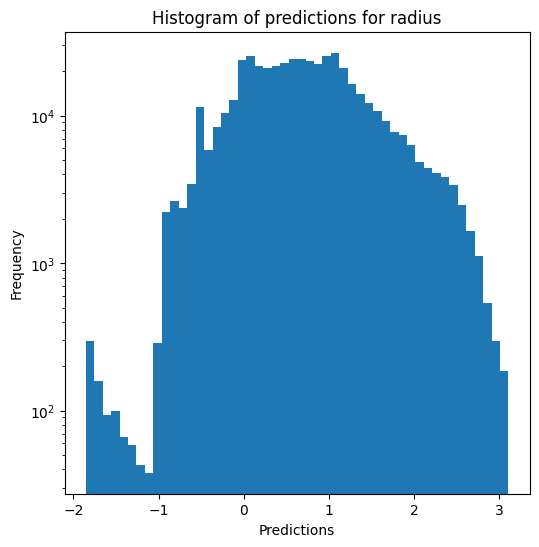

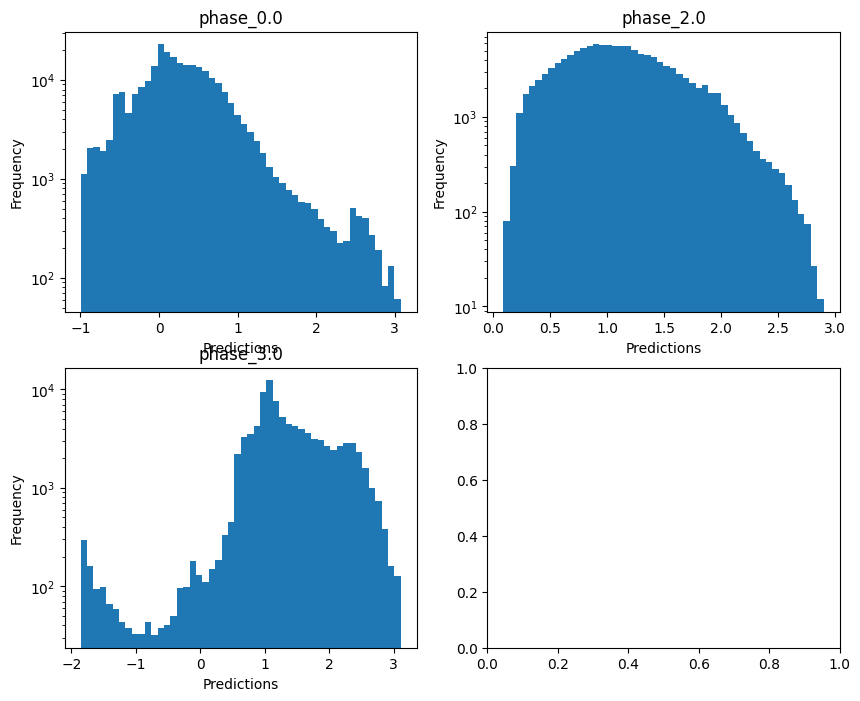

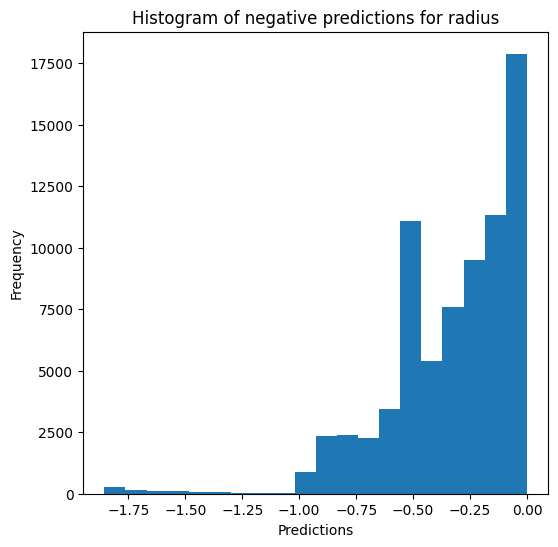

Saving predictions and results...


In [23]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True, n_jobs=5)
# average depth de 44-46

### XGBoost

In [24]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
0.0999979840073621 - 298.5447575808816

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9908710963304506
  RMSE :  2.514906110748476
  MAE :  0.678937428029162
  MedAE :  0.12432344904301651
  CORR :  0.9954416412886717
  MAX_ER :  77.88077842758253
  Percentiles : 
    75th percentile :  0.3826112767092287
    90th percentile :  1.287106158837679
    95th percentile :  2.6951015938528253
    99th percentile :  11.0779457521317

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9988885012661332
  RMSE :  0.9838705702250511
  MAE :  0.29128972450632473
  MedAE :  0.07114267534736629
  CORR :  0.9994779616634689
  MAX_ER :  32.875938708616275
  Percentiles : 
    75th percentile :  0.15861711260196798
    90th percentile :  0.5477893564105578
    95

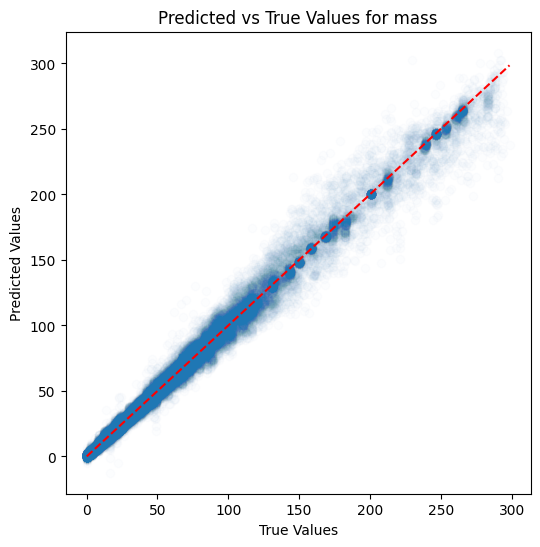

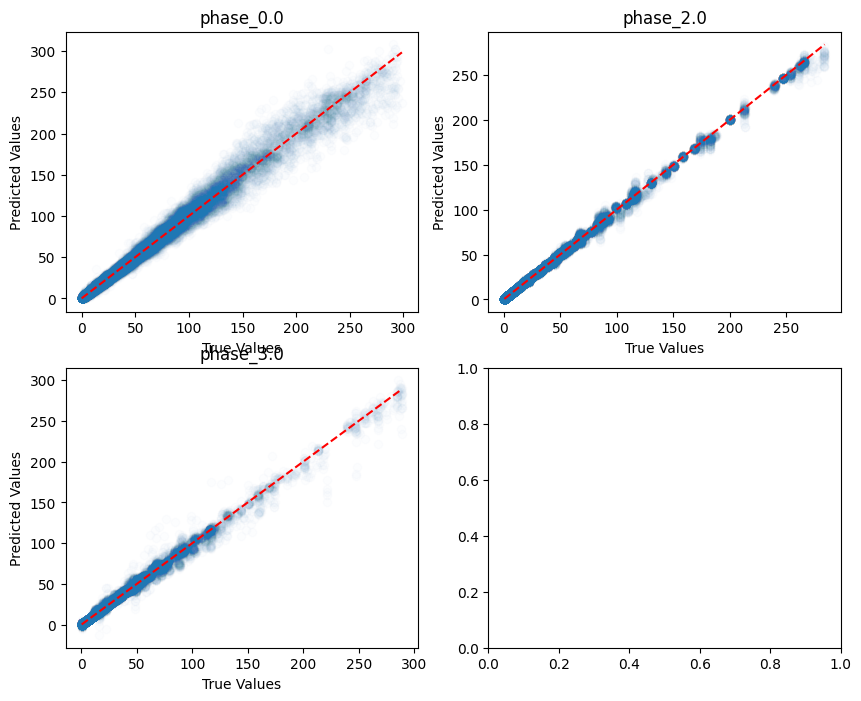

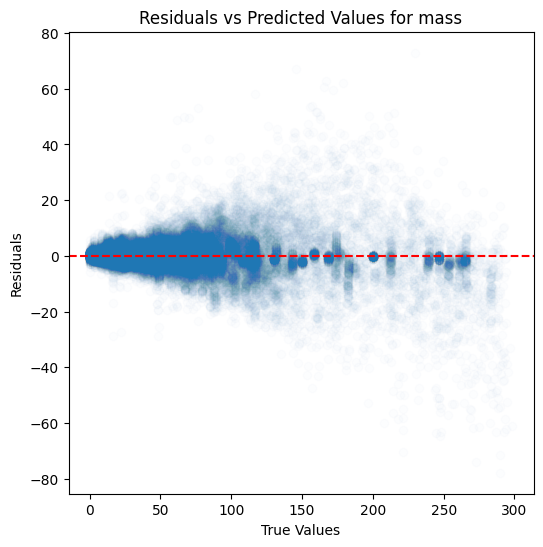

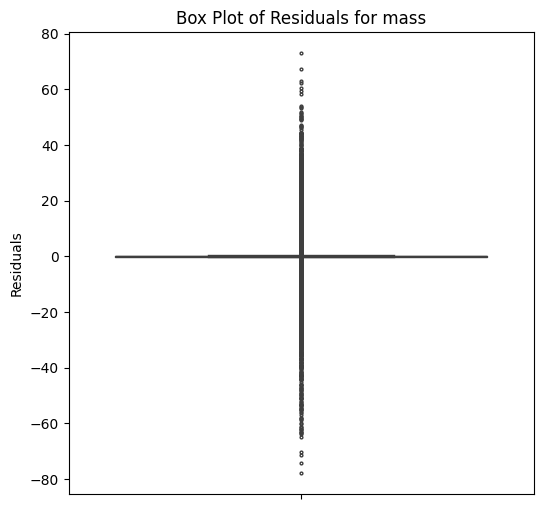

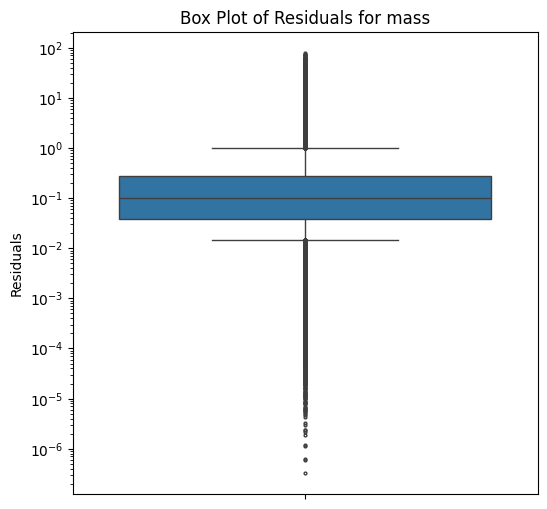

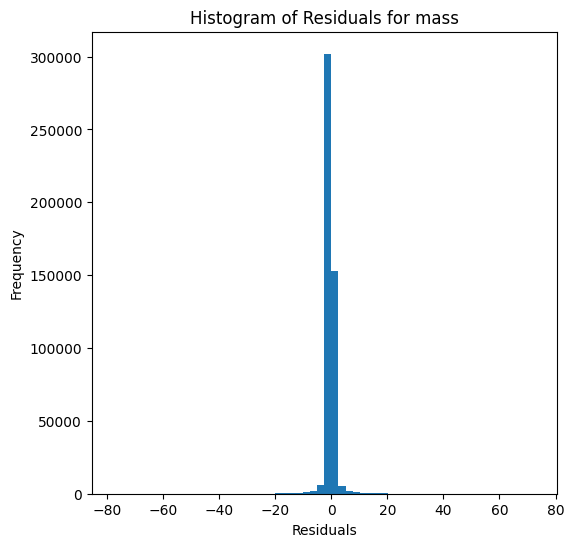

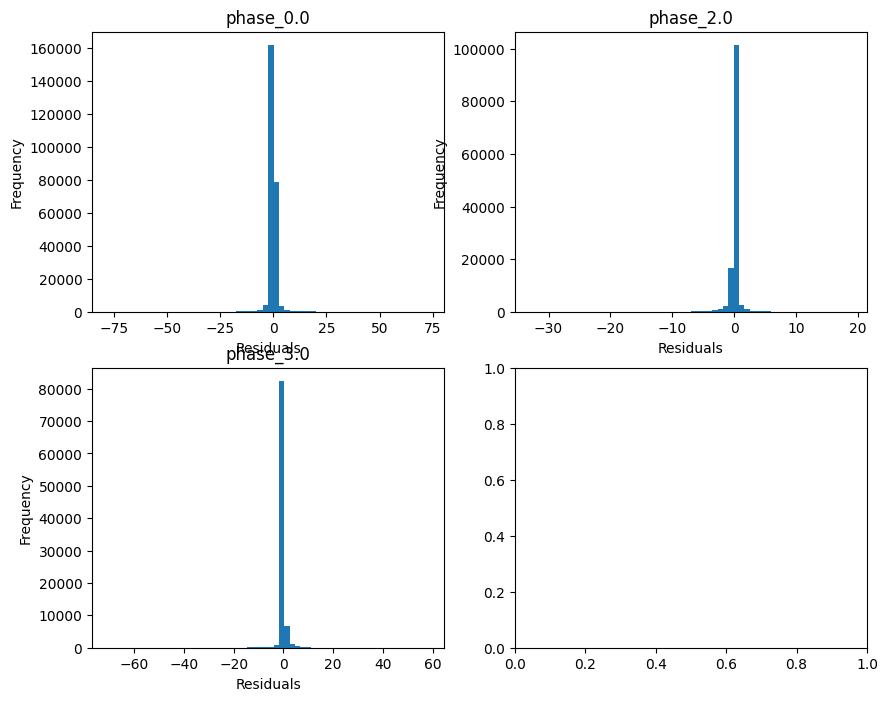

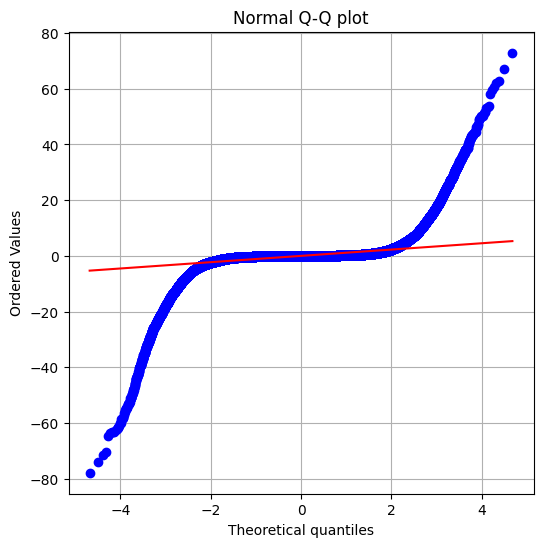

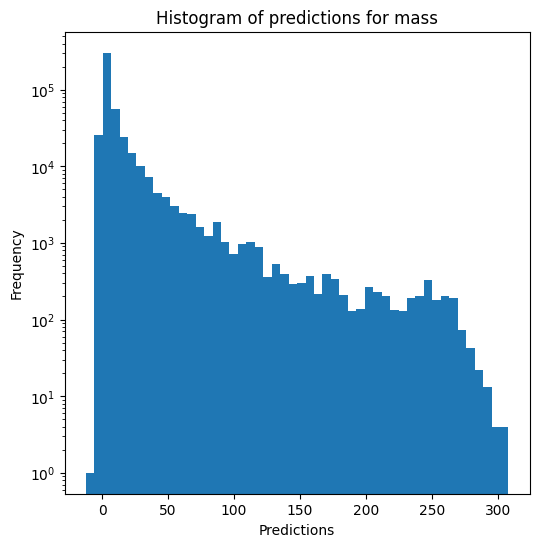

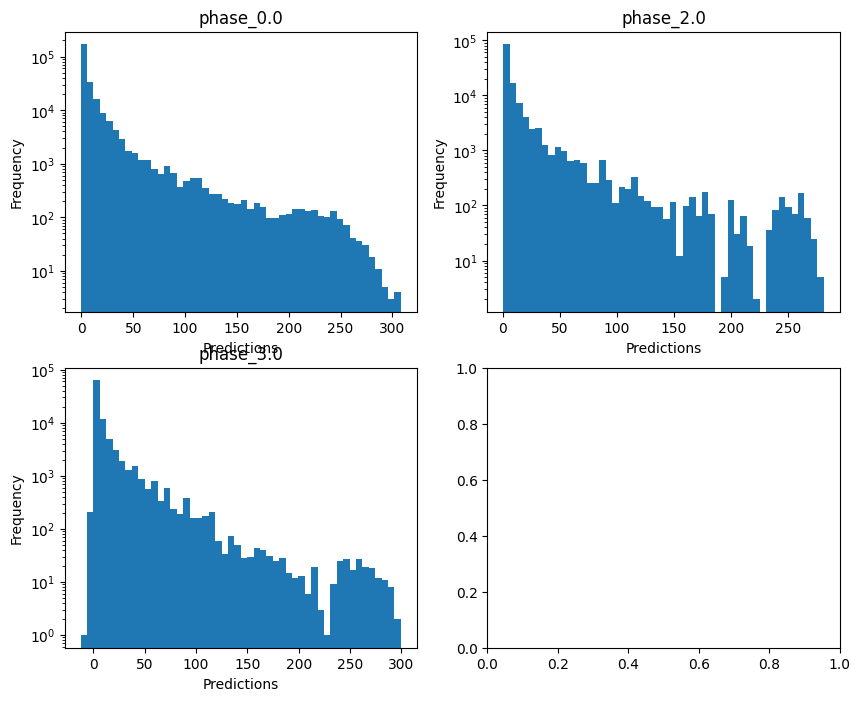

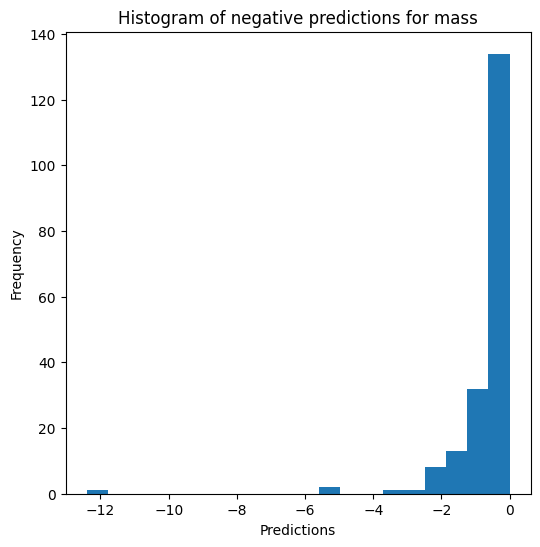

-1.861069007171269 - 3.1297545143214007

radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9994453815539737
  RMSE :  0.013439001546194694
  MAE :  0.009891559775160166
  MedAE :  0.00747479628313269
  CORR :  0.9997226713831151
  MAX_ER :  0.12641478753552815
  Percentiles : 
    75th percentile :  0.013594348429983916
    90th percentile :  0.021352833985476705
    95th percentile :  0.027246851008655825
    99th percentile :  0.04187617980992569

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.900376516729969
  RVE :  0.9991837368887836
  RMSE :  0.014058380710206752
  MAE :  0.010954257700611949
  MedAE :  0.008935811729372745
  CORR :  0.9995923346285195
  MAX_ER :  0.11285984737620902
  Percentiles : 
    75th percentile :  0.015530409611607676
    90th percentile :  0.022909424580061233
    95th percentile :  0.02798022847013998
    99th percentile :  0.

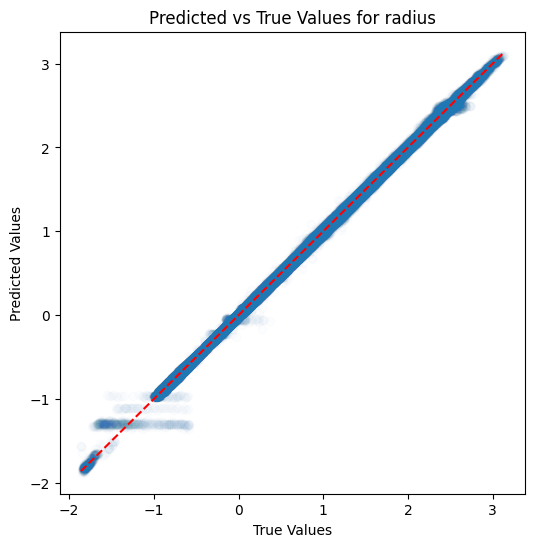

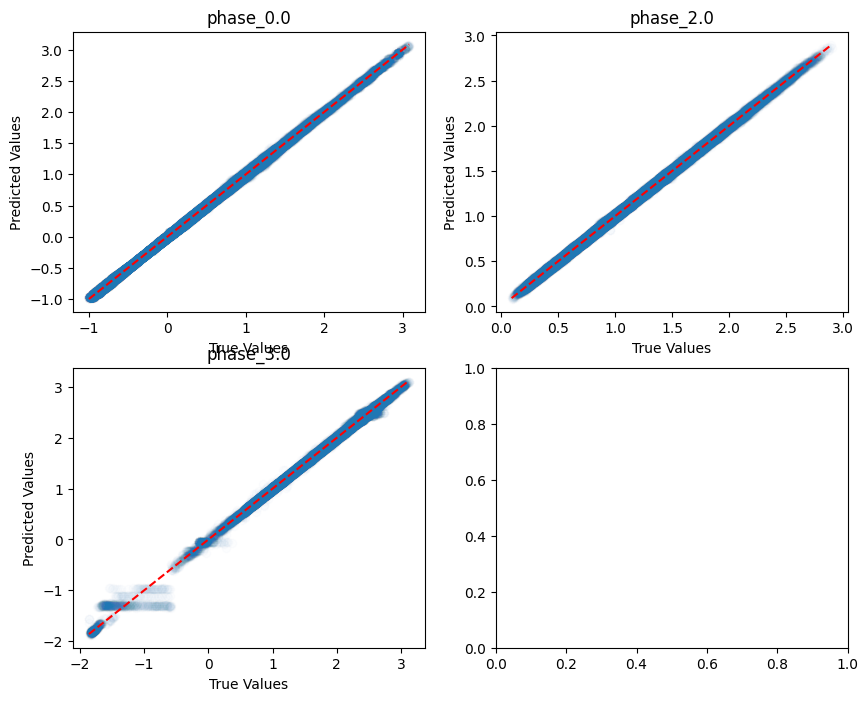

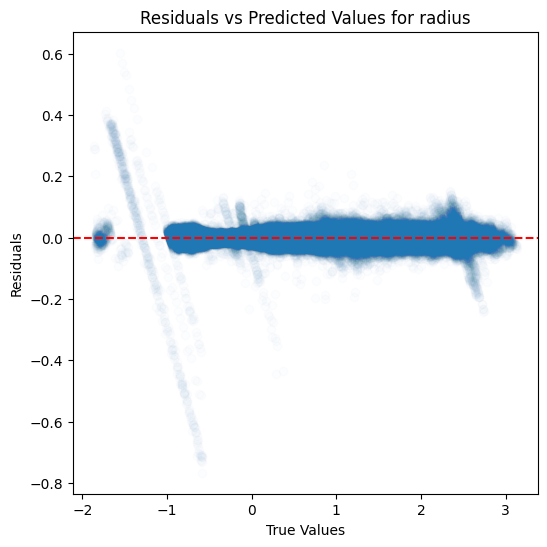

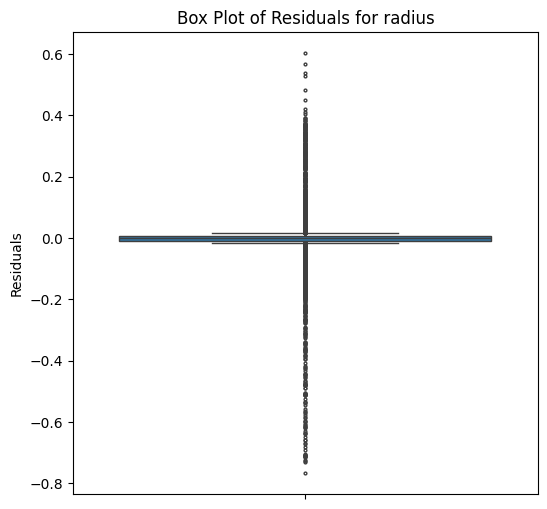

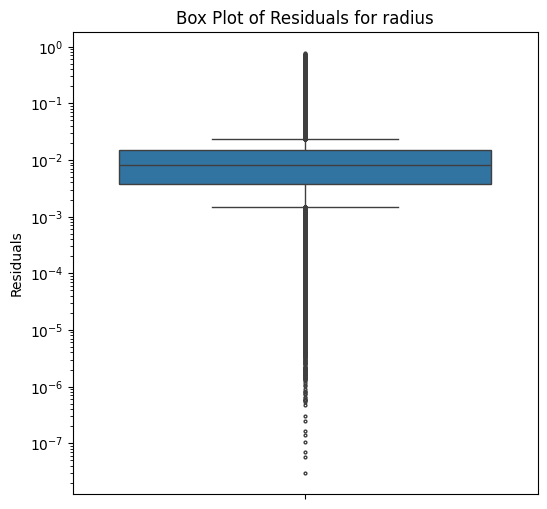

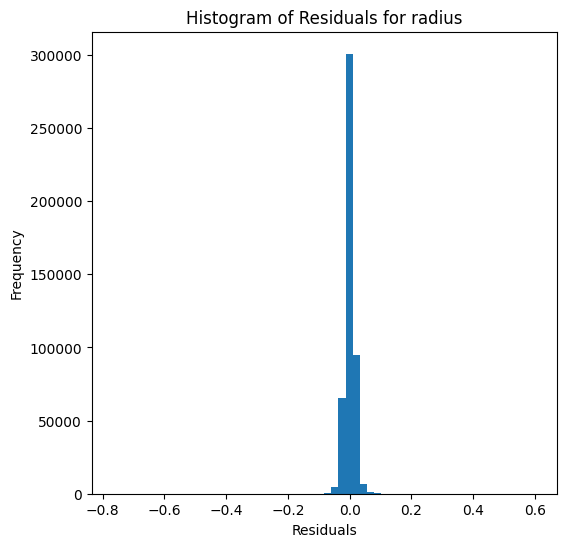

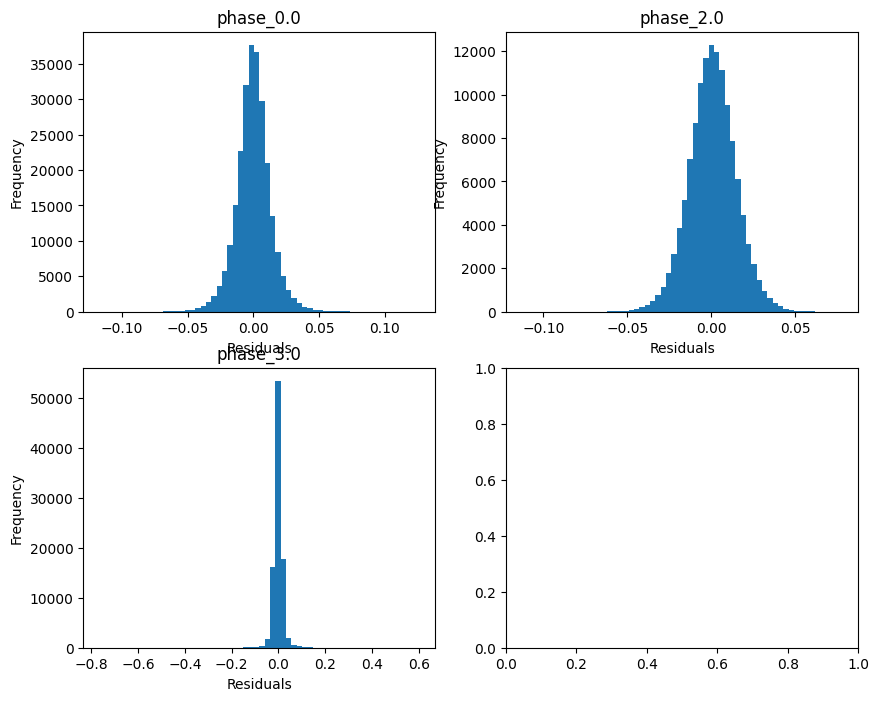

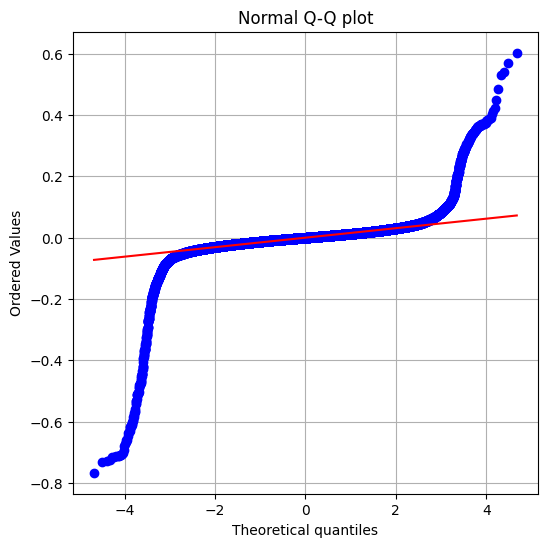

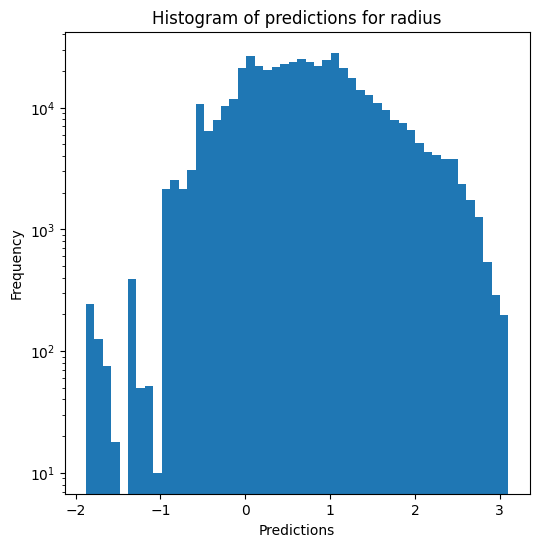

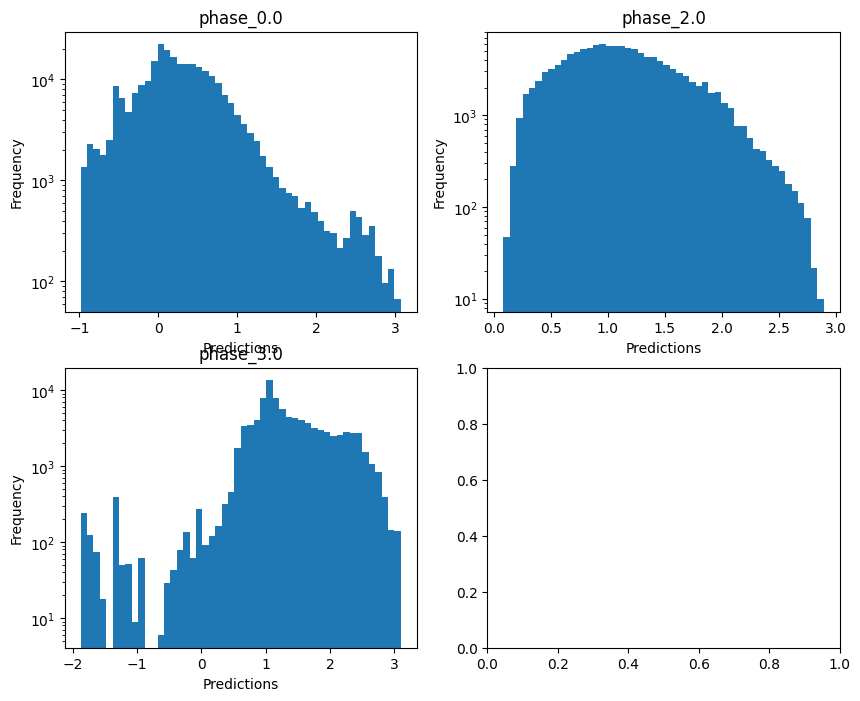

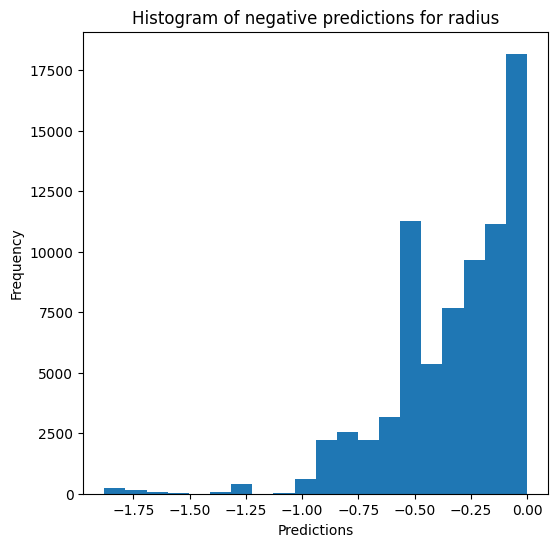

Saving predictions and results...


In [25]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True, n_jobs=5)

### Multi-layer perceptron

In [26]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


2.8869230353352773
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


2.9504884094337154
3 

...

3.055558922832427
9 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


3.3290322616042904
10 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


3.218546176305844

Evaluating predictions...
0.0999979840073621 - 298.5447575808816

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9773820324481238
  RMSE :  3.95862127178362
  MAE :  1.2683189565782882
  MedAE :  0.34378579828647826
  CORR :  0.9886455202254096
  MAX_ER :  117.17703972831201
  Percentiles : 
    75th percentile :  0.8251710846231974
    90th percentile :  2.7945903250680293
    95th percentile :  5.267880708296979
    99th percentile :  16.50806222067419

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9890498010673133
  RMSE :  3.0873430818500243
  MAE :  1.000194475352368
  MedAE :  0.29067196877702234
  CORR :  0.9948611783335205
  MAX_ER :  82.05802657945026
  Percentiles : 
    75th percentile :  0.6066459815200014
    90th percentile :  2.2069338591612127
    95th percentile :  3.7133167346517846
    99th percen

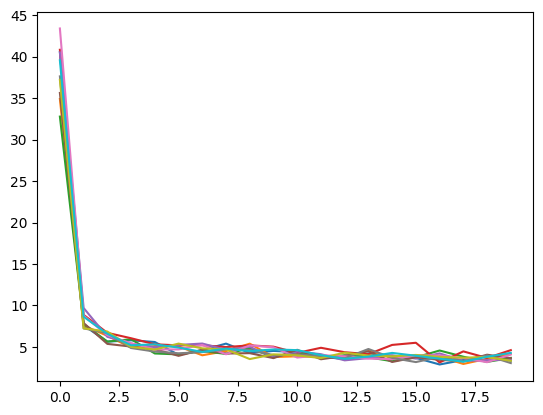

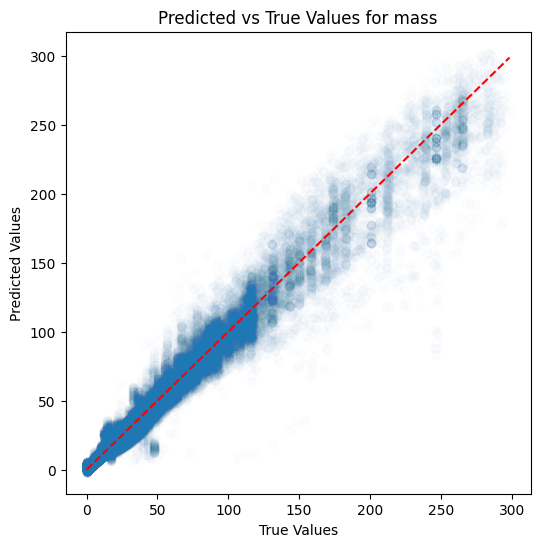

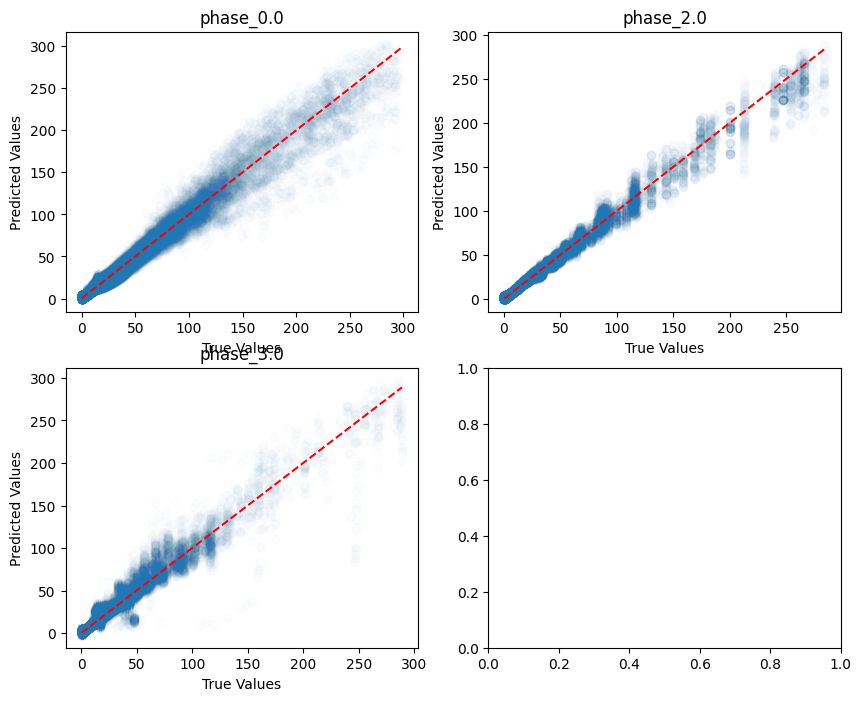

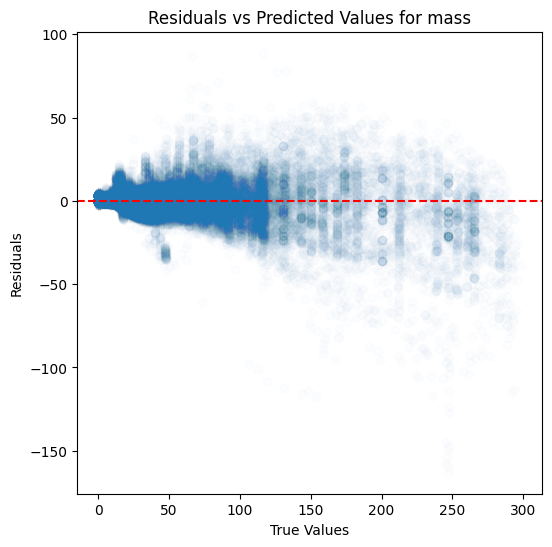

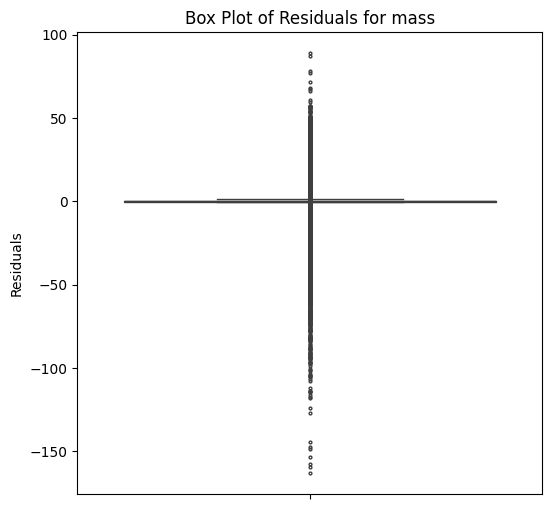

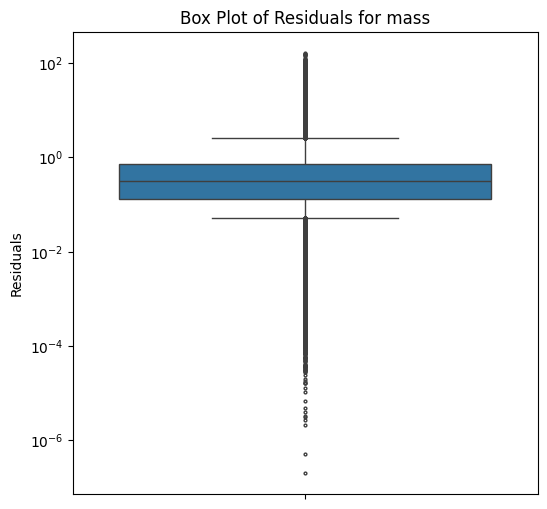

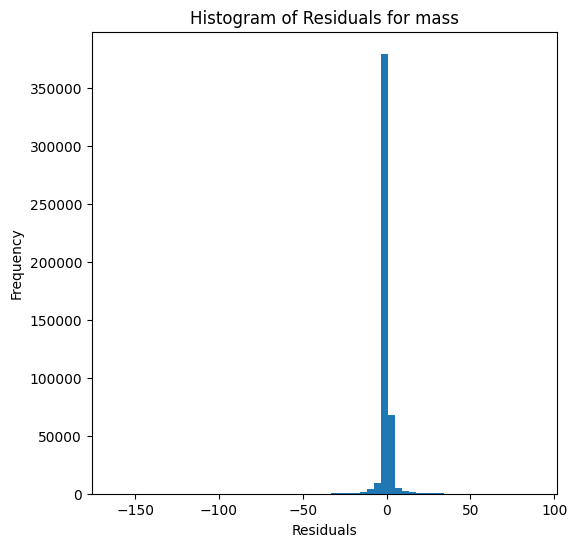

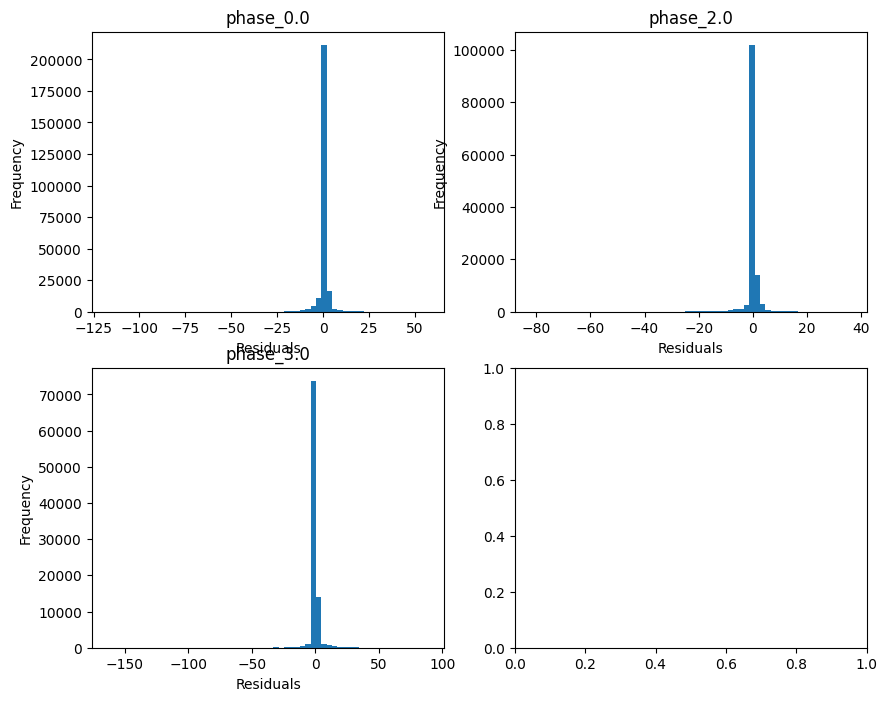

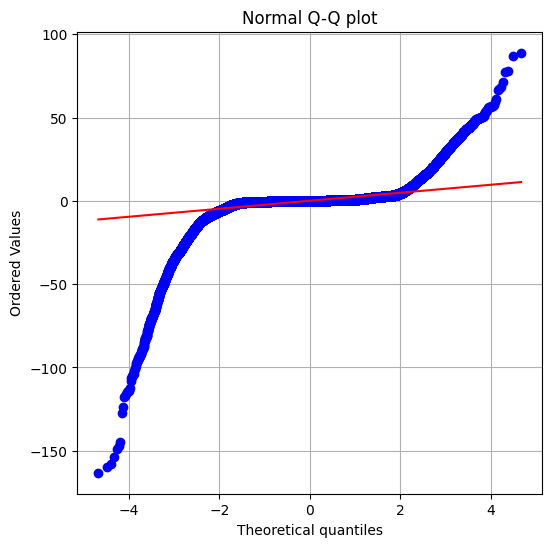

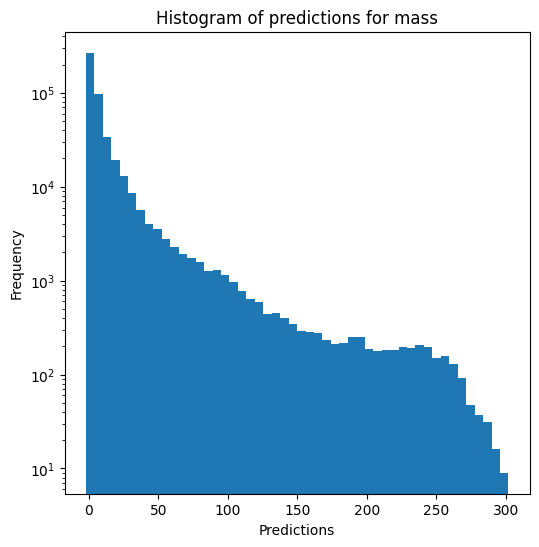

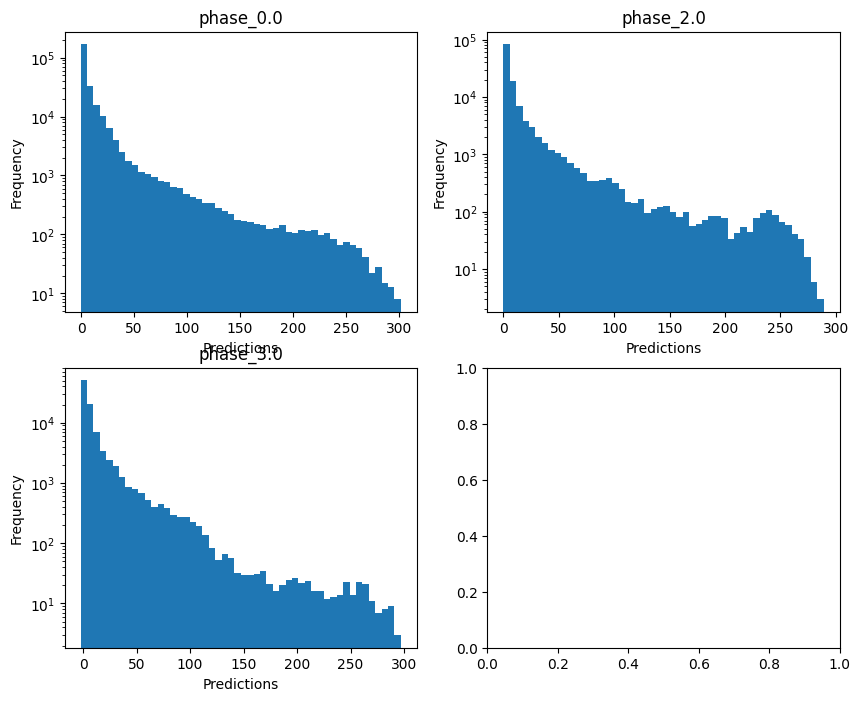

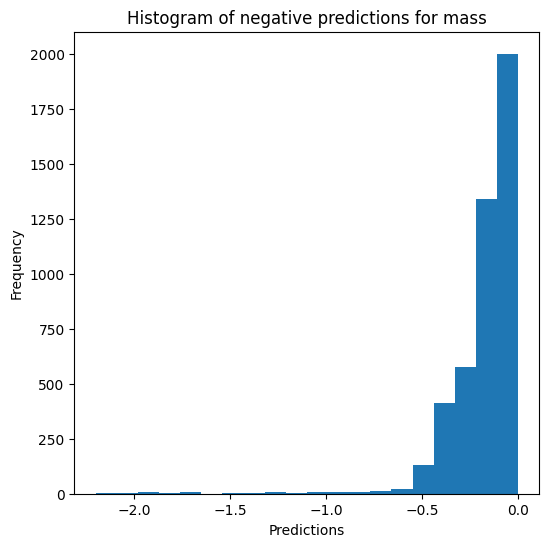

-1.861069007171269 - 3.1297545143214007

radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9754861361846096
  RMSE :  0.0909881002561968
  MAE :  0.06376711052819783
  MedAE :  0.04471249135521488
  CORR :  0.9878791368934834
  MAX_ER :  0.5223335924874889
  Percentiles : 
    75th percentile :  0.08220504583354964
    90th percentile :  0.1416742089132644
    95th percentile :  0.21288528748381627
    99th percentile :  0.3111726473789386

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.900376516729969
  RVE :  0.9631384053179481
  RMSE :  0.09772101567582336
  MAE :  0.06562476159464888
  MedAE :  0.04380711242323043
  CORR :  0.9818963992395894
  MAX_ER :  0.4684602519572878
  Percentiles : 
    75th percentile :  0.07877443740265
    90th percentile :  0.1474630699731685
    95th percentile :  0.24458605010342385
    99th percentile :  0.34017454200068553



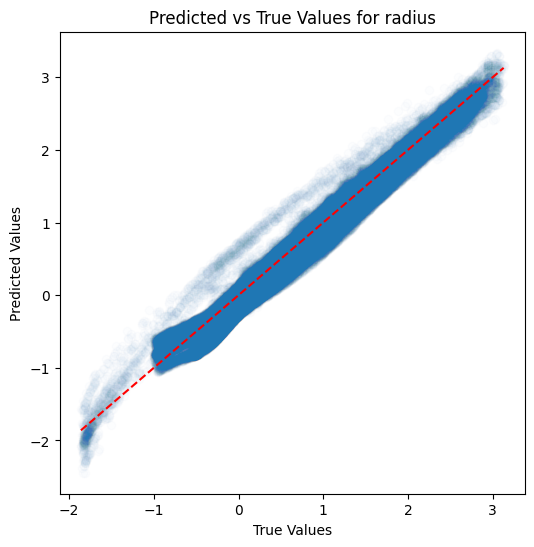

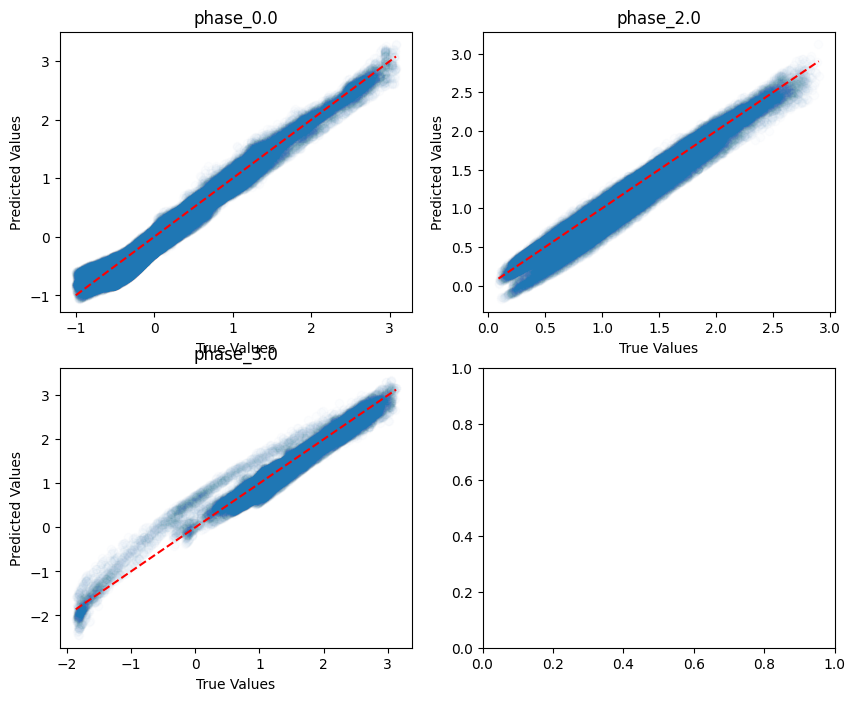

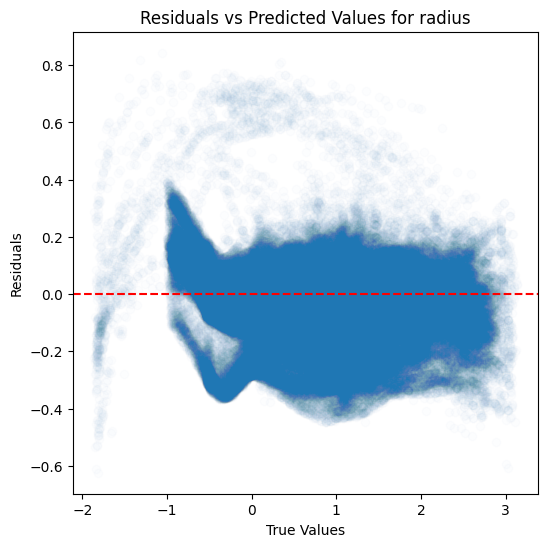

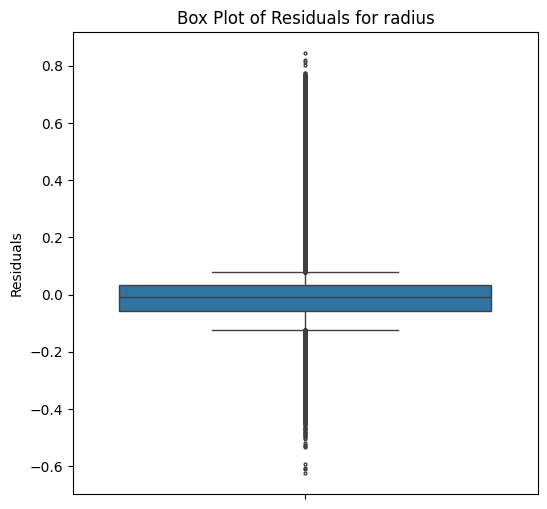

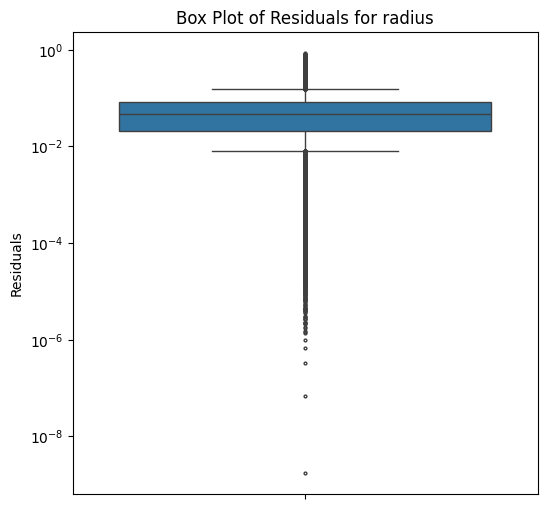

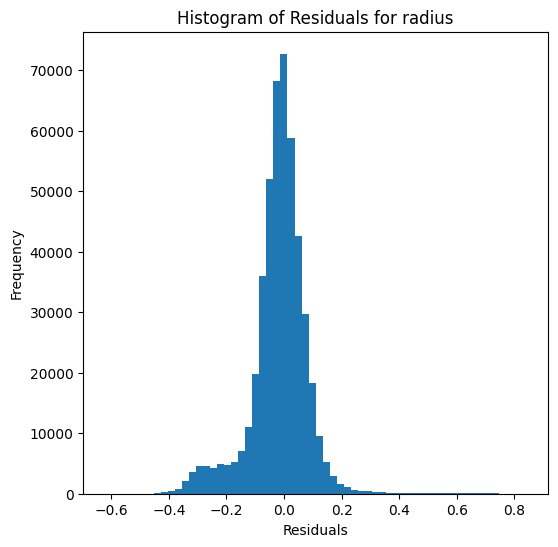

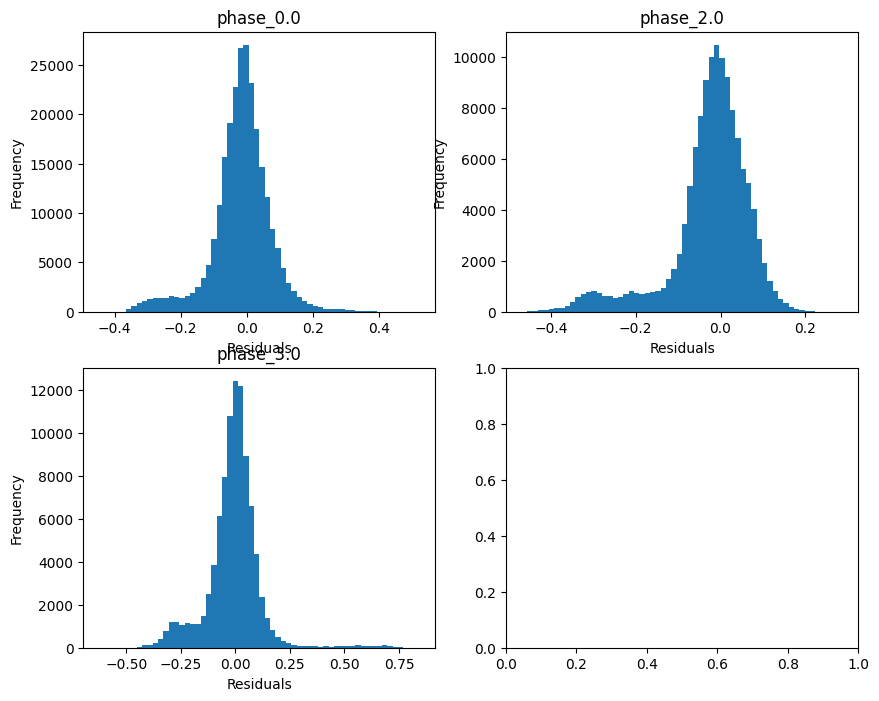

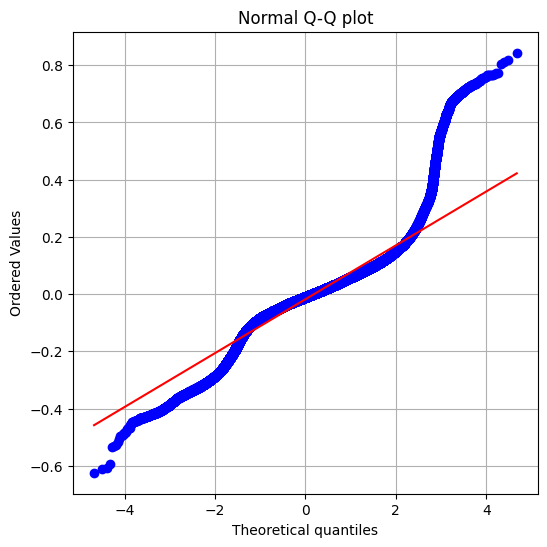

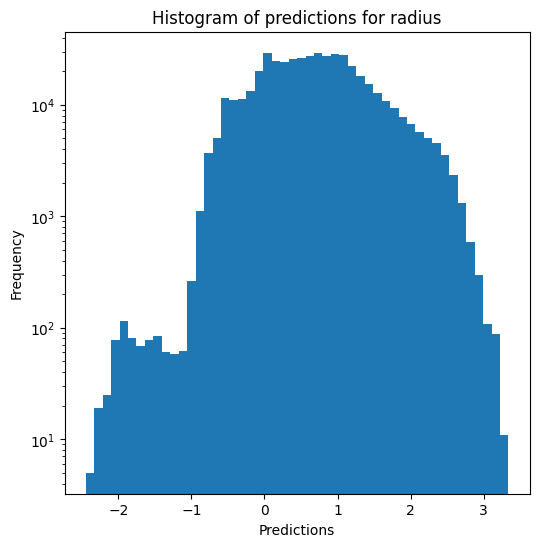

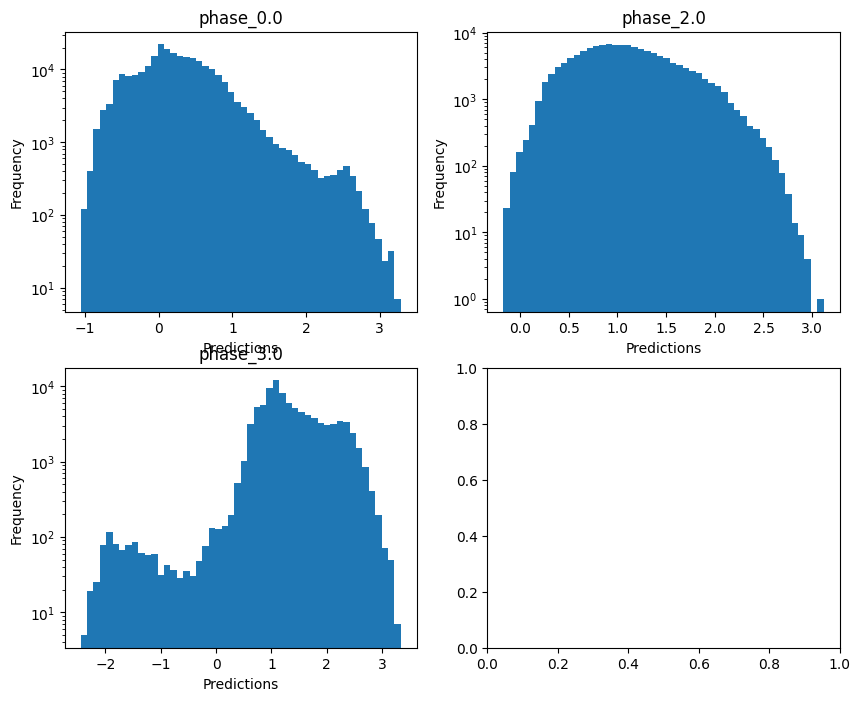

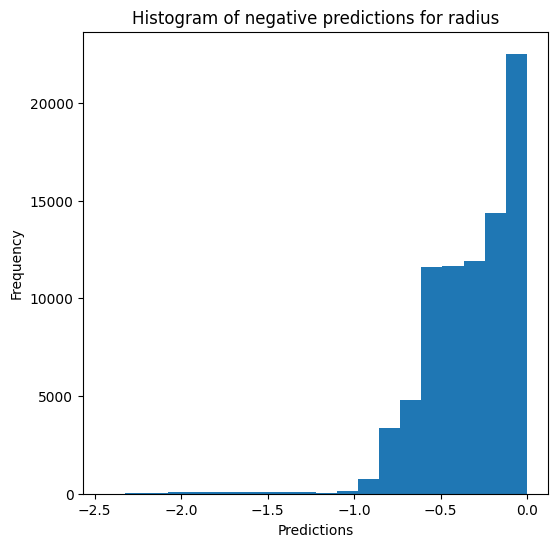

Saving predictions and results...


In [27]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=True, use_preds=False, save=True, show=True,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon